In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/BigContest_JSH/BigContest/지수현')

import dask.dataframe as dd
import time
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

Mounted at /content/drive


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [4]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 60.5 MB/s eta 0:00:00


# 여의도 귀가 top5

In [5]:
stay_ddf = dd.read_csv('/content/drive/MyDrive/BigContest_JSH/BigContest/data/stay_all.csv', assume_missing=True)

In [6]:
stay_ddf

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts
npartitions=144,,,,,,,,
,float64,float64,float64,string,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [7]:
# 축제 지역 매핑과 목적 코드 매핑
dest_hdong_Stop5 = {1156053500: 'Stop5', 1144066000: 'Stop5', 1156056000: 'Stop5', 1159051000: 'Stop5', 1144059000: 'Stop5'}
purpose_Stop5 = {0: '귀가', 1: '업무', 2: '학업', 3: '쇼핑여가', 4: '기타', 5: '여행'}

# 축제 기간 정의 (YYYYMMDD 형식)
festival_periods_Stop5 = {
    1156053500.0: ('20231007', '20231007'),
    1144066000.0: ('20231007', '20231007'),
    1156056000.0: ('20231007', '20231007'),
    1159051000.0: ('20231007', '20231007'),
    1144059000.0: ('20231007', '20231007')
}

# 축제 기간 정보를 Dask DataFrame으로 생성
festival_periods_df_Stop5 = pd.DataFrame({
    'hdong_cd': festival_periods_Stop5.keys(),
    'start_date': [int(period[0]) for period in festival_periods_Stop5.values()],
    'end_date': [int(period[1]) for period in festival_periods_Stop5.values()]
})
festival_periods_ddf_Stop5 = dd.from_pandas(festival_periods_df_Stop5, npartitions=1)

# Dask로 stay 데이터 로드
stay_ddf_Stop5 = dd.read_csv('/content/drive/MyDrive/BigContest_JSH/BigContest/data/stay_all.csv', assume_missing=True)

stay_ddf_Stop5

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts
npartitions=144,,,,,,,,
,float64,float64,float64,string,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [8]:
# 필요한 컬럼의 형 변환 및 매핑 적용
stay_ddf_Stop5['hdong_cd'] = stay_ddf_Stop5['hdong_cd'].astype(float)
stay_ddf_Stop5['date'] = stay_ddf_Stop5['date'].astype(int)
stay_ddf_Stop5['gender'] = stay_ddf_Stop5['gender'].astype(int)
stay_ddf_Stop5['age'] = stay_ddf_Stop5['age'].astype(int)
stay_ddf_Stop5['stay_cnts'] = stay_ddf_Stop5['stay_cnts'].astype(int)

stay_ddf_Stop5['purpose'] = stay_ddf_Stop5['purpose'].map(purpose_Stop5)
stay_ddf_Stop5['Destination'] = stay_ddf_Stop5['hdong_cd'].map(dest_hdong_Stop5)

# 축제 기간 정보와 병합
stay_ddf_Stop5 = stay_ddf_Stop5.merge(festival_periods_ddf_Stop5, on='hdong_cd', how='left')

# 축제 기간 여부 컬럼 추가
stay_ddf_Stop5['is_festival'] = (stay_ddf_Stop5['date'] >= stay_ddf_Stop5['start_date']) & (stay_ddf_Stop5['date'] <= stay_ddf_Stop5['end_date'])

# 필요한 데이터만 Pandas로 변환
filtered_stay_Stop5 = stay_ddf_Stop5[stay_ddf_Stop5['is_festival']].compute()
filtered_stay_Stop5 = filtered_stay_Stop5.drop(['start_date', 'end_date'], axis=1)

# 결과 확인
print(filtered_stay_Stop5.head())
print()
filtered_stay_Stop5
print()
print(filtered_stay_Stop5.dtypes)

         Unnamed: 0      hdong_cd      date   time  gender  age purpose  \
1034897       232.0  1.159051e+09  20231007  21:00       1    2      여행   
1035446       781.0  1.156054e+09  20231007  14:00       1    7    쇼핑여가   
1035491       826.0  1.156056e+09  20231007  23:00       1    4      귀가   
1035504       839.0  1.144066e+09  20231007  08:00       1    6      귀가   
1035699      1034.0  1.159051e+09  20231007  16:00       1    3      기타   

         stay_cnts Destination  is_festival  
1034897        875       Stop5         True  
1035446        685       Stop5         True  
1035491       2227       Stop5         True  
1035504       1184       Stop5         True  
1035699        639       Stop5         True  


Unnamed: 0             float64
hdong_cd               float64
date                     int64
time           string[pyarrow]
gender                   int64
age                      int64
purpose        string[pyarrow]
stay_cnts                int64
Destination    string[p

In [9]:
# 'hdong_cd'와 'stay_cnts' 열의 형식을 다시 지정
filtered_stay_Stop5['hdong_cd'] = filtered_stay_Stop5['hdong_cd'].astype(int)
filtered_stay_Stop5['stay_cnts'] = filtered_stay_Stop5['stay_cnts'].astype(int)

# 변경된 데이터 확인
print(filtered_stay_Stop5.head())

         Unnamed: 0    hdong_cd      date   time  gender  age purpose  \
1034897       232.0  1159051000  20231007  21:00       1    2      여행   
1035446       781.0  1156053500  20231007  14:00       1    7    쇼핑여가   
1035491       826.0  1156056000  20231007  23:00       1    4      귀가   
1035504       839.0  1144066000  20231007  08:00       1    6      귀가   
1035699      1034.0  1159051000  20231007  16:00       1    3      기타   

         stay_cnts Destination  is_festival  
1034897        875       Stop5         True  
1035446        685       Stop5         True  
1035491       2227       Stop5         True  
1035504       1184       Stop5         True  
1035699        639       Stop5         True  


In [10]:
# 목적이 '귀가'인 데이터 필터링 후 'Unnamed: 0' 열 제거
filtered_stay_h_Stop5 = filtered_stay_Stop5[filtered_stay_Stop5['purpose'] == '귀가'].drop(columns='Unnamed: 0', errors='ignore')
print(filtered_stay_h_Stop5.head())

           hdong_cd      date   time  gender  age purpose  stay_cnts  \
1035491  1156056000  20231007  23:00       1    4      귀가       2227   
1035504  1144066000  20231007  08:00       1    6      귀가       1184   
1035857  1144059000  20231007  19:00       0    3      귀가       1413   
1035993  1159051000  20231007  22:00       0    0      귀가       1453   
1036011  1144066000  20231007  23:00       1    4      귀가       2003   

        Destination  is_festival  
1035491       Stop5         True  
1035504       Stop5         True  
1035857       Stop5         True  
1035993       Stop5         True  
1036011       Stop5         True  


In [11]:
# 목적이 귀가인 "서울 여의동 방문지역 Top5"
filtered_stay_h_S_Stop5=filtered_stay_h_Stop5[(filtered_stay_h_Stop5['Destination']=='Stop5') & (filtered_stay_h_Stop5['date']== 20231007)]
filtered_stay_h_S_Stop5

,hdong_cd,date,time,gender,age,purpose,stay_cnts,Destination,is_festival
1035491,1156056000,20231007,23:00,1,4,귀가,2227,Stop5,True
1035504,1144066000,20231007,08:00,1,6,귀가,1184,Stop5,True
1035857,1144059000,20231007,19:00,0,3,귀가,1413,Stop5,True
1035993,1159051000,20231007,22:00,0,0,귀가,1453,Stop5,True
1036011,1144066000,20231007,23:00,1,4,귀가,2003,Stop5,True
...,...,...,...,...,...,...,...,...,...
780012,1156053500,20231007,15:00,1,8,귀가,177,Stop5,True
780037,1156053500,20231007,19:00,1,8,귀가,187,Stop5,True
792477,1156053500,20231007,20:00,1,0,귀가,204,Stop5,True
795652,1156053500,20231007,23:00,1,8,귀가,198,Stop5,True


<ipython-input-12-82d69fa0f334>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_Stop5, palette='pastel')


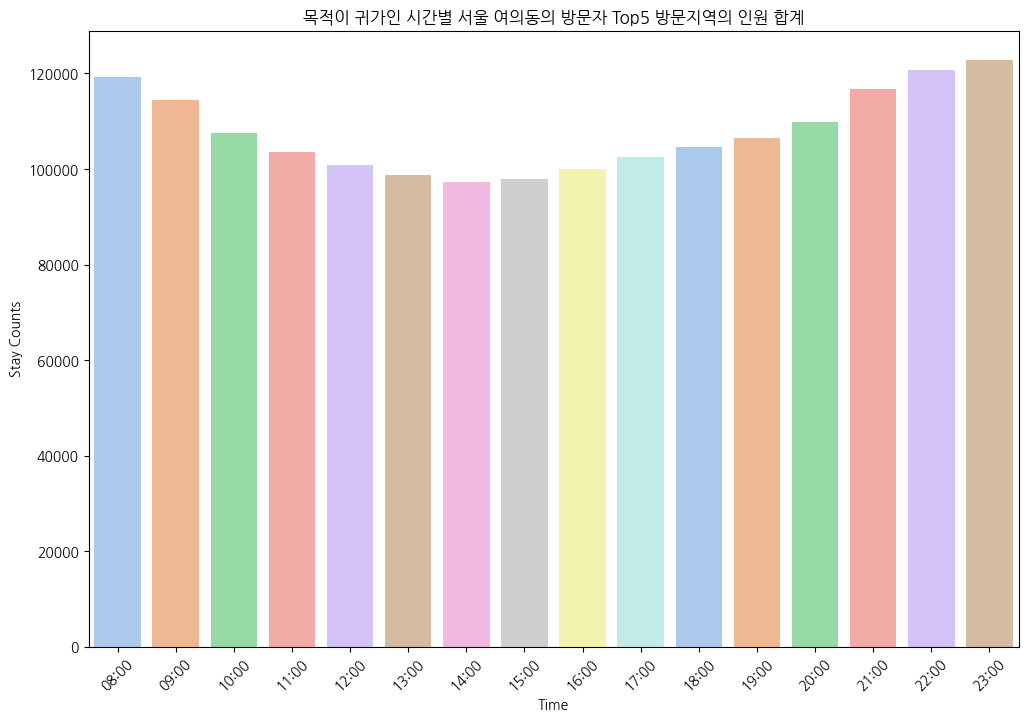

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
filtered_stay_h_S_Stop5 = filtered_stay_h_S_Stop5.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_Stop5 = filtered_stay_h_S_Stop5.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_Stop5, palette='pastel')
plt.title('목적이 귀가인 시간별 서울 여의동의 방문자 Top5 방문지역의 인원 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

# 부산 귀가 top5

In [22]:
# 축제 지역 매핑과 목적 코드 매핑
dest_hdong_Btop5 = {2635065000: 'Btop5', 2635052500: 'Btop5', 2635051000: 'Btop5', 2650080000: 'Btop5', 2635053000: 'Btop5'}
purpose_Btop5 = {0: '귀가', 1: '업무', 2: '학업', 3: '쇼핑여가', 4: '기타', 5: '여행'}

# 축제 기간 정의 (YYYYMMDD 형식)
festival_periods_Btop5 = {
    2635065000: ('20231006', '20231009'),
    2635052500: ('20231006', '20231009'),
    2635051000: ('20231006', '20231009'),
    2650080000: ('20231006', '20231009'),
    2635053000: ('20231006', '20231009')
}

# 축제 기간 정보를 Dask DataFrame으로 생성
festival_periods_df_Btop5 = pd.DataFrame({
    'hdong_cd': festival_periods_Btop5.keys(),
    'start_date': [int(period[0]) for period in festival_periods_Btop5.values()],
    'end_date': [int(period[1]) for period in festival_periods_Btop5.values()]
})
festival_periods_ddf_Btop5 = dd.from_pandas(festival_periods_df_Btop5, npartitions=1)

# Dask로 stay 데이터 로드
stay_ddf_Btop5 = dd.read_csv('/content/drive/MyDrive/BigContest_JSH/BigContest/data/stay_all.csv', assume_missing=True)

stay_ddf_Btop5

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts
npartitions=144,,,,,,,,
,float64,float64,float64,string,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [23]:
# 필요한 컬럼의 형 변환 및 매핑 적용
stay_ddf_Btop5['hdong_cd'] = stay_ddf_Btop5['hdong_cd'].astype(float)
stay_ddf_Btop5['date'] = stay_ddf_Btop5['date'].astype(int)
stay_ddf_Btop5['gender'] = stay_ddf_Btop5['gender'].astype(int)
stay_ddf_Btop5['age'] = stay_ddf_Btop5['age'].astype(int)
stay_ddf_Btop5['stay_cnts'] = stay_ddf_Btop5['stay_cnts'].astype(int)

stay_ddf_Btop5['purpose'] = stay_ddf_Btop5['purpose'].map(purpose_Btop5)
stay_ddf_Btop5['Destination'] = stay_ddf_Btop5['hdong_cd'].map(dest_hdong_Btop5)

# 축제 기간 정보와 병합
stay_ddf_Btop5 = stay_ddf_Btop5.merge(festival_periods_ddf_Btop5, on='hdong_cd', how='left')

# 축제 기간 여부 컬럼 추가
stay_ddf_Btop5['is_festival'] = (stay_ddf_Btop5['date'] >= stay_ddf_Btop5['start_date']) & (stay_ddf_Btop5['date'] <= stay_ddf_Btop5['end_date'])

# 필요한 데이터만 Pandas로 변환
filtered_stay_Btop5 = stay_ddf_Btop5[stay_ddf_Btop5['is_festival']].compute()
filtered_stay_Btop5 = filtered_stay_Btop5.drop(['start_date', 'end_date'], axis=1)

# 결과 확인
print(filtered_stay_Btop5.head())
print()
filtered_stay_Btop5
print()
print(filtered_stay_Btop5.dtypes)

         Unnamed: 0      hdong_cd      date   time  gender  age purpose  \
1035231       566.0  2.635053e+09  20231007  14:00       0    3      귀가   
1035431       766.0  2.650080e+09  20231007  20:00       0    5      귀가   
1036171      1506.0  2.650080e+09  20231007  19:00       1    5      귀가   
1036514      1849.0  2.635051e+09  20231007  12:00       1    2      여행   
1036815      2150.0  2.635051e+09  20231007  12:00       1    8      귀가   

         stay_cnts Destination  is_festival  
1035231        920       Btop5         True  
1035431       1110       Btop5         True  
1036171       1301       Btop5         True  
1036514       1570       Btop5         True  
1036815        758       Btop5         True  


Unnamed: 0             float64
hdong_cd               float64
date                     int64
time           string[pyarrow]
gender                   int64
age                      int64
purpose        string[pyarrow]
stay_cnts                int64
Destination    string[p

In [24]:
# 'hdong_cd'와 'stay_cnts' 열의 형식을 다시 지정
filtered_stay_Btop5['hdong_cd'] = filtered_stay_Btop5['hdong_cd'].astype(int)
filtered_stay_Btop5['stay_cnts'] = filtered_stay_Btop5['stay_cnts'].astype(int)

# 변경된 데이터 확인
print(filtered_stay_Btop5.head())
print()

# 목적이 '귀가'인 데이터 필터링 후 'Unnamed: 0' 열 제거
filtered_stay_h_Btop5 = filtered_stay_Btop5[filtered_stay_Btop5['purpose'] == '귀가'].drop(columns='Unnamed: 0', errors='ignore')
print(filtered_stay_h_Btop5.head())
print()

         Unnamed: 0    hdong_cd      date   time  gender  age purpose  \
1035231       566.0  2635053000  20231007  14:00       0    3      귀가   
1035431       766.0  2650080000  20231007  20:00       0    5      귀가   
1036171      1506.0  2650080000  20231007  19:00       1    5      귀가   
1036514      1849.0  2635051000  20231007  12:00       1    2      여행   
1036815      2150.0  2635051000  20231007  12:00       1    8      귀가   

         stay_cnts Destination  is_festival  
1035231        920       Btop5         True  
1035431       1110       Btop5         True  
1036171       1301       Btop5         True  
1036514       1570       Btop5         True  
1036815        758       Btop5         True  

           hdong_cd      date   time  gender  age purpose  stay_cnts  \
1035231  2635053000  20231007  14:00       0    3      귀가        920   
1035431  2650080000  20231007  20:00       0    5      귀가       1110   
1036171  2650080000  20231007  19:00       1    5      귀가       1301

In [25]:
# 목적이 귀가인 "부산광역시 해운대구 우2동 방문지역 Top5"
filtered_stay_h_B_Btop5=filtered_stay_h_Btop5[(filtered_stay_h_Btop5['Destination']=='Btop5') & (filtered_stay_h_Btop5['date']>= 20231004) & (filtered_stay_h_Btop5['date'] <= 20231013)]
filtered_stay_h_B_Btop5

,hdong_cd,date,time,gender,age,purpose,stay_cnts,Destination,is_festival
1035231,2635053000,20231007,14:00,0,3,귀가,920,Btop5,True
1035431,2650080000,20231007,20:00,0,5,귀가,1110,Btop5,True
1036171,2650080000,20231007,19:00,1,5,귀가,1301,Btop5,True
1036815,2635051000,20231007,12:00,1,8,귀가,758,Btop5,True
1036850,2635065000,20231007,16:00,1,3,귀가,1822,Btop5,True
...,...,...,...,...,...,...,...,...,...
390324,2635065000,20231009,17:00,0,8,귀가,151,Btop5,True
391474,2635053000,20231009,16:00,0,8,귀가,147,Btop5,True
393084,2635053000,20231009,17:00,0,8,귀가,157,Btop5,True
394206,2635065000,20231009,13:00,0,8,귀가,131,Btop5,True


<ipython-input-26-11c64b5d8741>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_Btop5, palette='pastel')


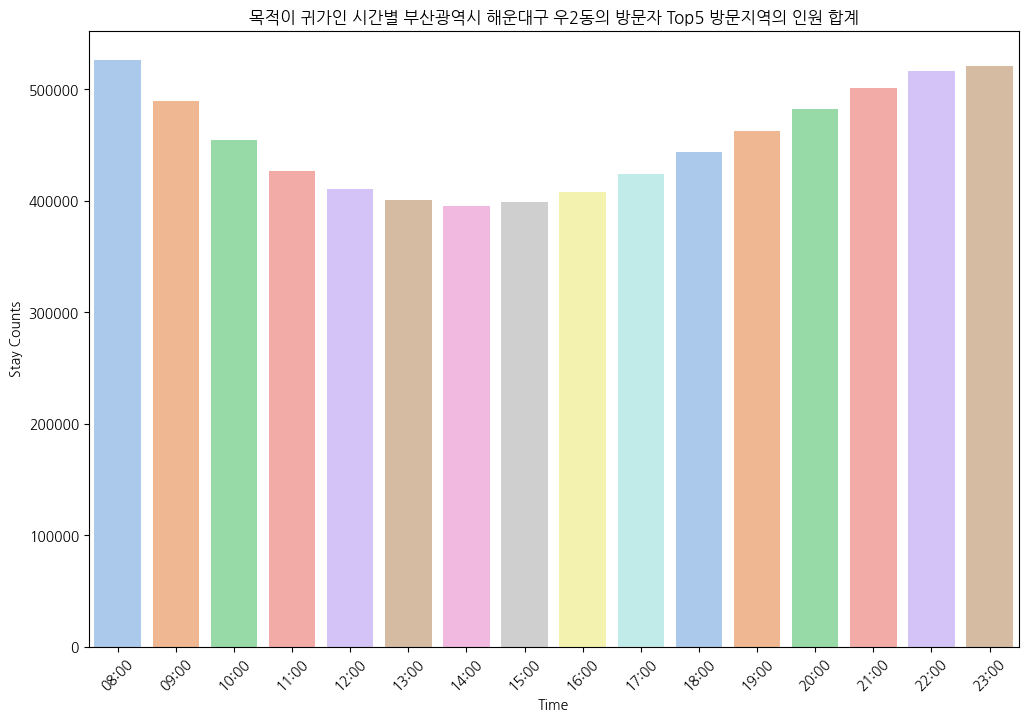

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
filtered_stay_h_B_Btop5 = filtered_stay_h_B_Btop5.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_Btop5 = filtered_stay_h_B_Btop5.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_Btop5, palette='pastel')
plt.title('목적이 귀가인 시간별 부산광역시 해운대구 우2동의 방문자 Top5 방문지역의 인원 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

# 대전 귀가 top5

In [ ]:
# 축제 지역 매핑과 목적 코드 매핑
dest_hdong_Dtop5 = {3020054000: 'Dtop5', 3020060000: 'Dtop5', 3017064000: 'Dtop5', 3017065000: 'Dtop5', 3020057000: 'Dtop5'}
purpose_Dtop5 = {0: '귀가', 1: '업무', 2: '학업', 3: '쇼핑여가', 4: '기타', 5: '여행'}

# 축제 기간 정의 (YYYYMMDD 형식)
festival_periods_Dtop5 = {
    3020054000: ('20231008', '20231010'),
    3020060000: ('20231008', '20231010'),
    3017064000: ('20231008', '20231010'),
    3017065000: ('20231008', '20231010'),
    3020057000: ('20231008', '20231010')
}

# 축제 기간 정보를 Dask DataFrame으로 생성
festival_periods_df_Dtop5 = pd.DataFrame({
    'hdong_cd': festival_periods_Dtop5.keys(),
    'start_date': [int(period[0]) for period in festival_periods_Dtop5.values()],
    'end_date': [int(period[1]) for period in festival_periods_Dtop5.values()]
})
festival_periods_ddf_Dtop5 = dd.from_pandas(festival_periods_df_Dtop5, npartitions=1)

# Dask로 stay 데이터 로드
stay_ddf_Dtop5 = dd.read_csv('/content/drive/MyDrive/BigContest_JSH/BigContest/data/stay_all.csv', assume_missing=True)

stay_ddf_Dtop5

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts
npartitions=144,,,,,,,,
,float64,float64,float64,string,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
# 필요한 컬럼의 형 변환 및 매핑 적용
stay_ddf_Dtop5['hdong_cd'] = stay_ddf_Dtop5['hdong_cd'].astype(float)
stay_ddf_Dtop5['date'] = stay_ddf_Dtop5['date'].astype(int)
stay_ddf_Dtop5['gender'] = stay_ddf_Dtop5['gender'].astype(int)
stay_ddf_Dtop5['age'] = stay_ddf_Dtop5['age'].astype(int)
stay_ddf_Dtop5['stay_cnts'] = stay_ddf_Dtop5['stay_cnts'].astype(int)

stay_ddf_Dtop5['purpose'] = stay_ddf_Dtop5['purpose'].map(purpose_Dtop5)
stay_ddf_Dtop5['Destination'] = stay_ddf_Dtop5['hdong_cd'].map(dest_hdong_Dtop5)

# 축제 기간 정보와 병합
stay_ddf_Dtop5 = stay_ddf_Dtop5.merge(festival_periods_ddf_Dtop5, on='hdong_cd', how='left')

# 축제 기간 여부 컬럼 추가
stay_ddf_Dtop5['is_festival'] = (stay_ddf_Dtop5['date'] >= stay_ddf_Dtop5['start_date']) & (stay_ddf_Dtop5['date'] <= stay_ddf_Dtop5['end_date'])

# 필요한 데이터만 Pandas로 변환
filtered_stay_Dtop5 = stay_ddf_Dtop5[stay_ddf_Dtop5['is_festival']].compute()
filtered_stay_Dtop5 = filtered_stay_Dtop5.drop(['start_date', 'end_date'], axis=1)

# 결과 확인
print(filtered_stay_Dtop5.head())
print()
filtered_stay_Dtop5
print()
print(filtered_stay_Dtop5.dtypes)

        Unnamed: 0      hdong_cd      date   time  gender  age purpose  \
446370       363.0  3.020054e+09  20231008  12:00       1    2      여행   
446536       529.0  3.020054e+09  20231008  13:00       1    3      귀가   
448800      2793.0  3.020054e+09  20231008  14:00       0    4      귀가   
448832      2825.0  3.017064e+09  20231008  19:00       0    2      기타   
448889      2882.0  3.020054e+09  20231008  23:00       1    1      귀가   

        stay_cnts Destination  is_festival  
446370        883       Dtop5         True  
446536       1742       Dtop5         True  
448800       1853       Dtop5         True  
448832        740       Dtop5         True  
448889       3176       Dtop5         True  


Unnamed: 0             float64
hdong_cd               float64
date                     int64
time           string[pyarrow]
gender                   int64
age                      int64
purpose        string[pyarrow]
stay_cnts                int64
Destination    string[pyarrow]
is_f

In [ ]:
# 'hdong_cd'와 'stay_cnts' 열의 형식을 다시 지정
filtered_stay_Dtop5['hdong_cd'] = filtered_stay_Dtop5['hdong_cd'].astype(int)
filtered_stay_Dtop5['stay_cnts'] = filtered_stay_Dtop5['stay_cnts'].astype(int)

# 변경된 데이터 확인
print(filtered_stay_Dtop5.head())
print()

# 목적이 '귀가'인 데이터 필터링 후 'Unnamed: 0' 열 제거
filtered_stay_h_Dtop5 = filtered_stay_Dtop5[filtered_stay_Dtop5['purpose'] == '귀가'].drop(columns='Unnamed: 0', errors='ignore')
print(filtered_stay_h_Dtop5.head())
print()

        Unnamed: 0    hdong_cd      date   time  gender  age purpose  \
446370       363.0  3020054000  20231008  12:00       1    2      여행   
446536       529.0  3020054000  20231008  13:00       1    3      귀가   
448800      2793.0  3020054000  20231008  14:00       0    4      귀가   
448832      2825.0  3017064000  20231008  19:00       0    2      기타   
448889      2882.0  3020054000  20231008  23:00       1    1      귀가   

        stay_cnts Destination  is_festival  
446370        883       Dtop5         True  
446536       1742       Dtop5         True  
448800       1853       Dtop5         True  
448832        740       Dtop5         True  
448889       3176       Dtop5         True  

          hdong_cd      date   time  gender  age purpose  stay_cnts  \
446536  3020054000  20231008  13:00       1    3      귀가       1742   
448800  3020054000  20231008  14:00       0    4      귀가       1853   
448889  3020054000  20231008  23:00       1    1      귀가       3176   
449527  3020

In [ ]:
# 목적이 귀가인 "대전광역시 유성구 도룡동 방문지역 Top5"
filtered_stay_h_D_Dtop5=filtered_stay_h_Dtop5[(filtered_stay_h_Dtop5['Destination']=='Dtop5') & (filtered_stay_h_Dtop5['date']>= 20231008) & (filtered_stay_h_Dtop5['date'] <= 20231010)]
filtered_stay_h_D_Dtop5

,hdong_cd,date,time,gender,age,purpose,stay_cnts,Destination,is_festival
446536,3020054000,20231008,13:00,1,3,귀가,1742,Dtop5,True
448800,3020054000,20231008,14:00,0,4,귀가,1853,Dtop5,True
448889,3020054000,20231008,23:00,1,1,귀가,3176,Dtop5,True
449527,3020060000,20231008,21:00,0,3,귀가,1670,Dtop5,True
449938,3020054000,20231008,13:00,1,6,귀가,798,Dtop5,True
...,...,...,...,...,...,...,...,...,...
824887,3017065000,20231010,08:00,0,8,귀가,40,Dtop5,True
863578,3017065000,20231010,19:00,0,8,귀가,34,Dtop5,True
884153,3017065000,20231010,12:00,0,8,귀가,32,Dtop5,True
884194,3017065000,20231010,11:00,0,8,귀가,34,Dtop5,True


<ipython-input-104-572f84c5aa56>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_Dtop5, palette='pastel')


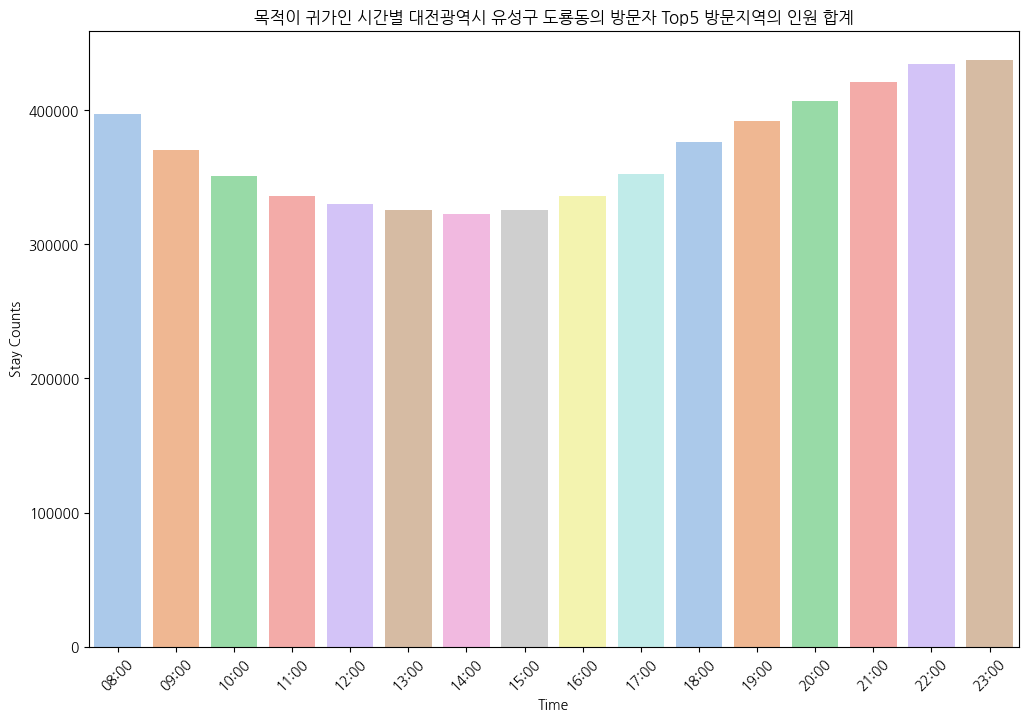

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
filtered_stay_h_D_Dtop5 = filtered_stay_h_D_Dtop5.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_Dtop5 = filtered_stay_h_D_Dtop5.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_Dtop5, palette='pastel')
plt.title('목적이 귀가인 시간별 대전광역시 유성구 도룡동의 방문자 Top5 방문지역의 인원 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

# 강릉(스피드스케이트장) 귀가 top5

In [ ]:
# 축제 지역 매핑과 목적 코드 매핑
dest_hdong_Gtop5 = {5115057100: 'Gtop5', 5115066500: 'Gtop5', 5115059000: 'Gtop5', 5115064500: 'Gtop5', 5115055000: 'Gtop5'}
purpose_Gtop5 = {0: '귀가', 1: '업무', 2: '학업', 3: '쇼핑여가', 4: '기타', 5: '여행'}

# 축제 기간 정의 (YYYYMMDD 형식)
festival_periods_Gtop5 = {
    5115057100: ('20231012', '20231015'),
    5115066500: ('20231012', '20231015'),
    5115059000: ('20231012', '20231015'),
    5115064500: ('20231012', '20231015'),
    5115055000: ('20231012', '20231015')
}

# 축제 기간 정보를 Dask DataFrame으로 생성
festival_periods_df_Gtop5 = pd.DataFrame({
    'hdong_cd': festival_periods_Gtop5.keys(),
    'start_date': [int(period[0]) for period in festival_periods_Gtop5.values()],
    'end_date': [int(period[1]) for period in festival_periods_Gtop5.values()]
})
festival_periods_ddf_Gtop5 = dd.from_pandas(festival_periods_df_Gtop5, npartitions=1)

# Dask로 stay 데이터 로드
stay_ddf_Gtop5 = dd.read_csv('/content/drive/MyDrive/BigContest_JSH/BigContest/data/stay_all.csv', assume_missing=True)

stay_ddf_Gtop5

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts
npartitions=144,,,,,,,,
,float64,float64,float64,string,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
# 필요한 컬럼의 형 변환 및 매핑 적용
stay_ddf_Gtop5['hdong_cd'] = stay_ddf_Gtop5['hdong_cd'].astype(float)
stay_ddf_Gtop5['date'] = stay_ddf_Gtop5['date'].astype(int)
stay_ddf_Gtop5['gender'] = stay_ddf_Gtop5['gender'].astype(int)
stay_ddf_Gtop5['age'] = stay_ddf_Gtop5['age'].astype(int)
stay_ddf_Gtop5['stay_cnts'] = stay_ddf_Gtop5['stay_cnts'].astype(int)

stay_ddf_Gtop5['purpose'] = stay_ddf_Gtop5['purpose'].map(purpose_Gtop5)
stay_ddf_Gtop5['Destination'] = stay_ddf_Gtop5['hdong_cd'].map(dest_hdong_Gtop5)

# 축제 기간 정보와 병합
stay_ddf_Gtop5 = stay_ddf_Gtop5.merge(festival_periods_ddf_Gtop5, on='hdong_cd', how='left')

# 축제 기간 여부 컬럼 추가
stay_ddf_Gtop5['is_festival'] = (stay_ddf_Gtop5['date'] >= stay_ddf_Gtop5['start_date']) & (stay_ddf_Gtop5['date'] <= stay_ddf_Gtop5['end_date'])

# 필요한 데이터만 Pandas로 변환
filtered_stay_Gtop5 = stay_ddf_Gtop5[stay_ddf_Gtop5['is_festival']].compute()
filtered_stay_Gtop5 = filtered_stay_Gtop5.drop(['start_date', 'end_date'], axis=1)

# 결과 확인
print(filtered_stay_Gtop5.head())
print()
filtered_stay_Gtop5
print()
print(filtered_stay_Gtop5.dtypes)

        Unnamed: 0      hdong_cd      date   time  gender  age purpose  \
166596       535.0  5.115055e+09  20231012  19:00       1    0      귀가   
167456      1395.0  5.115055e+09  20231012  11:00       1    5      귀가   
167877      1816.0  5.115055e+09  20231012  09:00       1    4      귀가   
168633      2572.0  5.115064e+09  20231012  20:00       0    2      귀가   
170750      4689.0  5.115055e+09  20231012  10:00       1    0      귀가   

        stay_cnts Destination  is_festival  
166596       1329       Gtop5         True  
167456       1170       Gtop5         True  
167877       1976       Gtop5         True  
168633        812       Gtop5         True  
170750       1269       Gtop5         True  


Unnamed: 0             float64
hdong_cd               float64
date                     int64
time           string[pyarrow]
gender                   int64
age                      int64
purpose        string[pyarrow]
stay_cnts                int64
Destination    string[pyarrow]
is_f

In [ ]:
# 'hdong_cd'와 'stay_cnts' 열의 형식을 다시 지정
filtered_stay_Gtop5['hdong_cd'] = filtered_stay_Gtop5['hdong_cd'].astype(int)
filtered_stay_Gtop5['stay_cnts'] = filtered_stay_Gtop5['stay_cnts'].astype(int)

# 변경된 데이터 확인
print(filtered_stay_Gtop5.head())
print()

# 목적이 '귀가'인 데이터 필터링 후 'Unnamed: 0' 열 제거
filtered_stay_h_Gtop5 = filtered_stay_Gtop5[filtered_stay_Gtop5['purpose'] == '귀가'].drop(columns='Unnamed: 0', errors='ignore')
print(filtered_stay_h_Gtop5.head())
print()

        Unnamed: 0    hdong_cd      date   time  gender  age purpose  \
166596       535.0  5115055000  20231012  19:00       1    0      귀가   
167456      1395.0  5115055000  20231012  11:00       1    5      귀가   
167877      1816.0  5115055000  20231012  09:00       1    4      귀가   
168633      2572.0  5115064500  20231012  20:00       0    2      귀가   
170750      4689.0  5115055000  20231012  10:00       1    0      귀가   

        stay_cnts Destination  is_festival  
166596       1329       Gtop5         True  
167456       1170       Gtop5         True  
167877       1976       Gtop5         True  
168633        812       Gtop5         True  
170750       1269       Gtop5         True  

          hdong_cd      date   time  gender  age purpose  stay_cnts  \
166596  5115055000  20231012  19:00       1    0      귀가       1329   
167456  5115055000  20231012  11:00       1    5      귀가       1170   
167877  5115055000  20231012  09:00       1    4      귀가       1976   
168633  5115

In [ ]:
# 목적이 귀가인 "강릉시 포남2동 스피드 스케이팅 경기장 방문지역 Top5"
filtered_stay_h_G_Gtop5=filtered_stay_h_Gtop5[(filtered_stay_h_Gtop5['Destination']=='Gtop5') & (filtered_stay_h_Gtop5['date']>= 20231012) & (filtered_stay_h_Gtop5['date'] <= 20231015)]
filtered_stay_h_G_Gtop5

,hdong_cd,date,time,gender,age,purpose,stay_cnts,Destination,is_festival
166596,5115055000,20231012,19:00,1,0,귀가,1329,Gtop5,True
167456,5115055000,20231012,11:00,1,5,귀가,1170,Gtop5,True
167877,5115055000,20231012,09:00,1,4,귀가,1976,Gtop5,True
168633,5115064500,20231012,20:00,0,2,귀가,812,Gtop5,True
170750,5115055000,20231012,10:00,1,0,귀가,1269,Gtop5,True
...,...,...,...,...,...,...,...,...,...
725986,5115059000,20231015,11:00,1,8,귀가,87,Gtop5,True
736423,5115059000,20231015,14:00,1,8,귀가,87,Gtop5,True
750528,5115059000,20231015,19:00,0,8,귀가,75,Gtop5,True
765642,5115066500,20231015,16:00,0,8,귀가,71,Gtop5,True


<ipython-input-114-ebfae6d32ee4>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_Gtop5, palette='pastel')


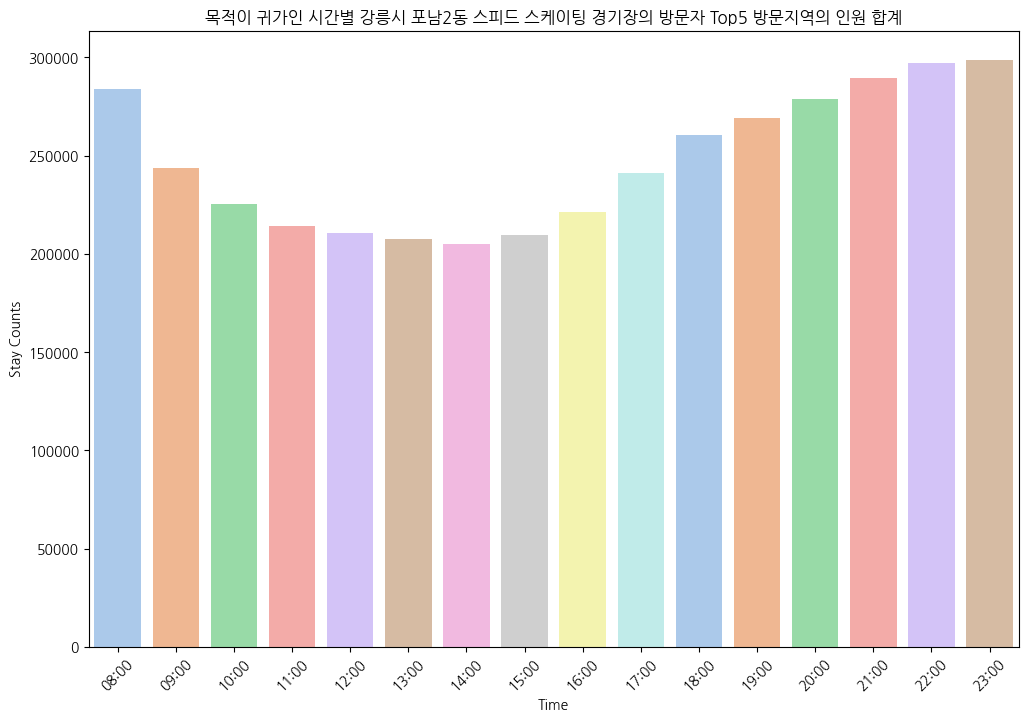

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
filtered_stay_h_G_Gtop5 = filtered_stay_h_G_Gtop5.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_Gtop5 = filtered_stay_h_G_Gtop5.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_Gtop5, palette='pastel')
plt.title('목적이 귀가인 시간별 강릉시 포남2동 스피드 스케이팅 경기장의 방문자 Top5 방문지역의 인원 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

# 강릉(경포호수공원) 귀가 top5

In [ ]:
# 축제 지역 매핑과 목적 코드 매핑
dest_hdong_G2top5 = {5115066500: 'G2top5', 5115057200: 'G2top5', 5115059000: 'G2top5', 5115064500: 'G2top5', 5115055000: 'G2top5'}
purpose_G2top5 = {0: '귀가', 1: '업무', 2: '학업', 3: '쇼핑여가', 4: '기타', 5: '여행'}

# 축제 기간 정의 (YYYYMMDD 형식)
festival_periods_G2top5 = {
    5115066500: ('20231012', '20231015'),
    5115057200: ('20231012', '20231015'),
    5115059000: ('20231012', '20231015'),
    5115064500: ('20231012', '20231015'),
    5115055000: ('20231012', '20231015')
}

# 축제 기간 정보를 Dask DataFrame으로 생성
festival_periods_df_G2top5 = pd.DataFrame({
    'hdong_cd': festival_periods_G2top5.keys(),
    'start_date': [int(period[0]) for period in festival_periods_G2top5.values()],
    'end_date': [int(period[1]) for period in festival_periods_G2top5.values()]
})
festival_periods_ddf_G2top5 = dd.from_pandas(festival_periods_df_G2top5, npartitions=1)

# Dask로 stay 데이터 로드
stay_ddf_G2top5 = dd.read_csv('/content/drive/MyDrive/BigContest_JSH/BigContest/data/stay_all.csv', assume_missing=True)

stay_ddf_G2top5

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts
npartitions=144,,,,,,,,
,float64,float64,float64,string,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
# 필요한 컬럼의 형 변환 및 매핑 적용
stay_ddf_G2top5['hdong_cd'] = stay_ddf_G2top5['hdong_cd'].astype(float)
stay_ddf_G2top5['date'] = stay_ddf_G2top5['date'].astype(int)
stay_ddf_G2top5['gender'] = stay_ddf_G2top5['gender'].astype(int)
stay_ddf_G2top5['age'] = stay_ddf_G2top5['age'].astype(int)
stay_ddf_G2top5['stay_cnts'] = stay_ddf_G2top5['stay_cnts'].astype(int)

stay_ddf_G2top5['purpose'] = stay_ddf_G2top5['purpose'].map(purpose_G2top5)
stay_ddf_G2top5['Destination'] = stay_ddf_G2top5['hdong_cd'].map(dest_hdong_G2top5)

# 축제 기간 정보와 병합
stay_ddf_G2top5 = stay_ddf_G2top5.merge(festival_periods_ddf_G2top5, on='hdong_cd', how='left')

# 축제 기간 여부 컬럼 추가
stay_ddf_G2top5['is_festival'] = (stay_ddf_G2top5['date'] >= stay_ddf_G2top5['start_date']) & (stay_ddf_G2top5['date'] <= stay_ddf_G2top5['end_date'])

# 필요한 데이터만 Pandas로 변환
filtered_stay_G2top5 = stay_ddf_G2top5[stay_ddf_G2top5['is_festival']].compute()
filtered_stay_G2top5 = filtered_stay_G2top5.drop(['start_date', 'end_date'], axis=1)

# 결과 확인
print(filtered_stay_G2top5.head())
print()
filtered_stay_G2top5
print()
print(filtered_stay_G2top5.dtypes)

        Unnamed: 0      hdong_cd      date   time  gender  age purpose  \
166596       535.0  5.115055e+09  20231012  19:00       1    0      귀가   
167456      1395.0  5.115055e+09  20231012  11:00       1    5      귀가   
167877      1816.0  5.115055e+09  20231012  09:00       1    4      귀가   
168633      2572.0  5.115064e+09  20231012  20:00       0    2      귀가   
170750      4689.0  5.115055e+09  20231012  10:00       1    0      귀가   

        stay_cnts Destination  is_festival  
166596       1329      G2top5         True  
167456       1170      G2top5         True  
167877       1976      G2top5         True  
168633        812      G2top5         True  
170750       1269      G2top5         True  


Unnamed: 0             float64
hdong_cd               float64
date                     int64
time           string[pyarrow]
gender                   int64
age                      int64
purpose        string[pyarrow]
stay_cnts                int64
Destination    string[pyarrow]
is_f

In [ ]:
# 'hdong_cd'와 'stay_cnts' 열의 형식을 다시 지정
filtered_stay_G2top5['hdong_cd'] = filtered_stay_G2top5['hdong_cd'].astype(int)
filtered_stay_G2top5['stay_cnts'] = filtered_stay_G2top5['stay_cnts'].astype(int)

# 변경된 데이터 확인
print(filtered_stay_G2top5.head())
print()

# 목적이 '귀가'인 데이터 필터링 후 'Unnamed: 0' 열 제거
filtered_stay_h_G2top5 = filtered_stay_G2top5[filtered_stay_G2top5['purpose'] == '귀가'].drop(columns='Unnamed: 0', errors='ignore')
print(filtered_stay_h_G2top5.head())
print()

        Unnamed: 0    hdong_cd      date   time  gender  age purpose  \
166596       535.0  5115055000  20231012  19:00       1    0      귀가   
167456      1395.0  5115055000  20231012  11:00       1    5      귀가   
167877      1816.0  5115055000  20231012  09:00       1    4      귀가   
168633      2572.0  5115064500  20231012  20:00       0    2      귀가   
170750      4689.0  5115055000  20231012  10:00       1    0      귀가   

        stay_cnts Destination  is_festival  
166596       1329      G2top5         True  
167456       1170      G2top5         True  
167877       1976      G2top5         True  
168633        812      G2top5         True  
170750       1269      G2top5         True  

          hdong_cd      date   time  gender  age purpose  stay_cnts  \
166596  5115055000  20231012  19:00       1    0      귀가       1329   
167456  5115055000  20231012  11:00       1    5      귀가       1170   
167877  5115055000  20231012  09:00       1    4      귀가       1976   
168633  5115

In [ ]:
# 목적이 귀가인 "강릉시 포남2동 스피드 스케이팅 경기장 방문지역 Top5"
filtered_stay_h_G2_G2top5=filtered_stay_h_G2top5[(filtered_stay_h_G2top5['Destination']=='G2top5') & (filtered_stay_h_G2top5['date']>= 20231012) & (filtered_stay_h_G2top5['date'] <= 20231015)]
filtered_stay_h_G2_G2top5

,hdong_cd,date,time,gender,age,purpose,stay_cnts,Destination,is_festival
166596,5115055000,20231012,19:00,1,0,귀가,1329,G2top5,True
167456,5115055000,20231012,11:00,1,5,귀가,1170,G2top5,True
167877,5115055000,20231012,09:00,1,4,귀가,1976,G2top5,True
168633,5115064500,20231012,20:00,0,2,귀가,812,G2top5,True
170750,5115055000,20231012,10:00,1,0,귀가,1269,G2top5,True
...,...,...,...,...,...,...,...,...,...
748528,5115057200,20231015,15:00,0,8,귀가,81,G2top5,True
750528,5115059000,20231015,19:00,0,8,귀가,75,G2top5,True
765642,5115066500,20231015,16:00,0,8,귀가,71,G2top5,True
773582,5115059000,20231015,11:00,0,8,귀가,77,G2top5,True


<ipython-input-121-6f3b129aaa86>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_G2top5, palette='pastel')


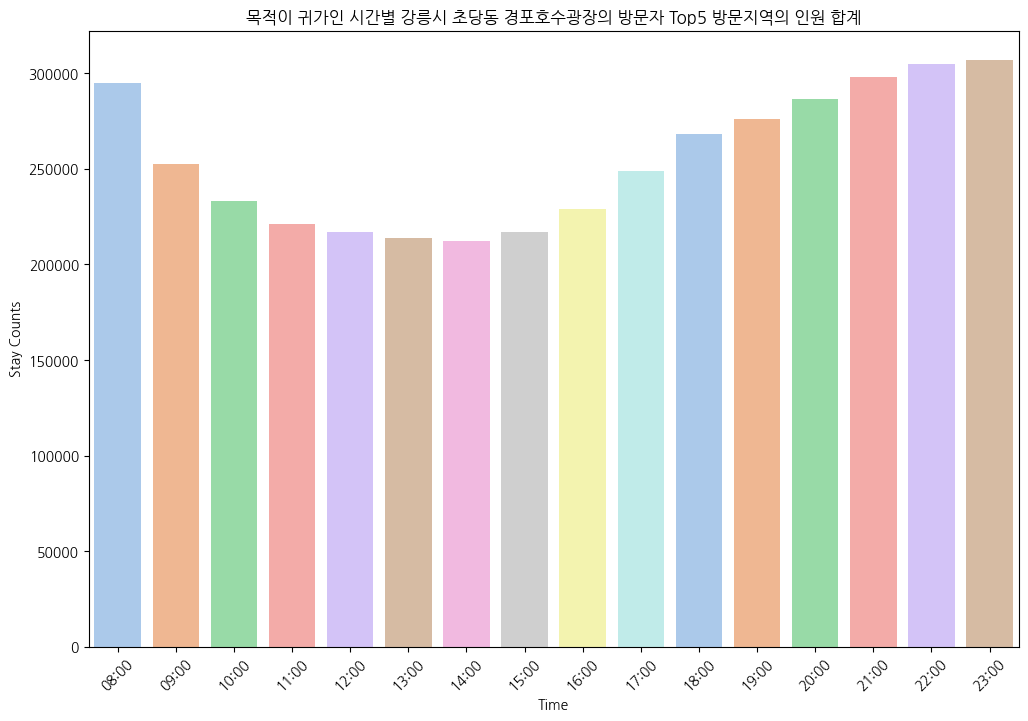

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
filtered_stay_h_G2_G2top5 = filtered_stay_h_G2_G2top5.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_G2top5 = filtered_stay_h_G2_G2top5.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_G2top5, palette='pastel')
plt.title('목적이 귀가인 시간별 강릉시 초당동 경포호수광장의 방문자 Top5 방문지역의 인원 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

# 임실 top5 귀가

In [ ]:
# 축제 지역 매핑과 목적 코드 매핑
dest_hdong_Itop5 = {4575025000: 'Itop5', 4511364100: 'Itop5', 4511169200: 'Itop5', 4511366500: 'Itop5', 4575032000: 'Itop5'}
purpose_Itop5 = {0: '귀가', 1: '업무', 2: '학업', 3: '쇼핑여가', 4: '기타', 5: '여행'}

# 축제 기간 정의 (YYYYMMDD 형식)
festival_periods_Itop5 = {
    4575025000: ('20231006', '20231009'),
    4511364100: ('20231006', '20231009'),
    4511169200: ('20231006', '20231009'),
    4511366500: ('20231006', '20231009'),
    4575032000: ('20231006', '20231009')
}

# 축제 기간 정보를 Dask DataFrame으로 생성
festival_periods_df_Itop5 = pd.DataFrame({
    'hdong_cd': festival_periods_Itop5.keys(),
    'start_date': [int(period[0]) for period in festival_periods_Itop5.values()],
    'end_date': [int(period[1]) for period in festival_periods_Itop5.values()]
})
festival_periods_ddf_Itop5 = dd.from_pandas(festival_periods_df_Itop5, npartitions=1)

# Dask로 stay 데이터 로드
stay_ddf_Itop5 = dd.read_csv('/content/drive/MyDrive/BigContest_JSH/BigContest/data/stay_all.csv', assume_missing=True)

stay_ddf_Itop5

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts
npartitions=144,,,,,,,,
,float64,float64,float64,string,float64,float64,float64,float64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


In [ ]:
# 필요한 컬럼의 형 변환 및 매핑 적용
stay_ddf_Itop5['hdong_cd'] = stay_ddf_Itop5['hdong_cd'].astype(float)
stay_ddf_Itop5['date'] = stay_ddf_Itop5['date'].astype(int)
stay_ddf_Itop5['gender'] = stay_ddf_Itop5['gender'].astype(int)
stay_ddf_Itop5['age'] = stay_ddf_Itop5['age'].astype(int)
stay_ddf_Itop5['stay_cnts'] = stay_ddf_Itop5['stay_cnts'].astype(int)

stay_ddf_Itop5['purpose'] = stay_ddf_Itop5['purpose'].map(purpose_Itop5)
stay_ddf_Itop5['Destination'] = stay_ddf_Itop5['hdong_cd'].map(dest_hdong_Itop5)

# 축제 기간 정보와 병합
stay_ddf_Itop5 = stay_ddf_Itop5.merge(festival_periods_ddf_Itop5, on='hdong_cd', how='left')

# 축제 기간 여부 컬럼 추가
stay_ddf_Itop5['is_festival'] = (stay_ddf_Itop5['date'] >= stay_ddf_Itop5['start_date']) & (stay_ddf_Itop5['date'] <= stay_ddf_Itop5['end_date'])

# 필요한 데이터만 Pandas로 변환
filtered_stay_Itop5 = stay_ddf_Itop5[stay_ddf_Itop5['is_festival']].compute()
filtered_stay_Itop5 = filtered_stay_Itop5.drop(['start_date', 'end_date'], axis=1)

# 결과 확인
print(filtered_stay_Itop5.head())
print()
filtered_stay_Itop5
print()
print(filtered_stay_Itop5.dtypes)

         Unnamed: 0      hdong_cd      date   time  gender  age purpose  \
1034999       334.0  4.511169e+09  20231007  08:00       0    0      귀가   
1035756      1091.0  4.511169e+09  20231007  22:00       0    4      귀가   
1036700      2035.0  4.511366e+09  20231007  10:00       0    1      귀가   
1037304      2639.0  4.511364e+09  20231007  23:00       1    7      귀가   
1037819      3154.0  4.511169e+09  20231007  22:00       1    0      귀가   

         stay_cnts Destination  is_festival  
1034999       2262       Itop5         True  
1035756       2941       Itop5         True  
1036700        663       Itop5         True  
1037304        685       Itop5         True  
1037819       1775       Itop5         True  


Unnamed: 0             float64
hdong_cd               float64
date                     int64
time           string[pyarrow]
gender                   int64
age                      int64
purpose        string[pyarrow]
stay_cnts                int64
Destination    string[p

In [ ]:
# 'hdong_cd'와 'stay_cnts' 열의 형식을 다시 지정
filtered_stay_Itop5['hdong_cd'] = filtered_stay_Itop5['hdong_cd'].astype(int)
filtered_stay_Itop5['stay_cnts'] = filtered_stay_Itop5['stay_cnts'].astype(int)

# 변경된 데이터 확인
print(filtered_stay_Itop5.head())
print()

# 목적이 '귀가'인 데이터 필터링 후 'Unnamed: 0' 열 제거
filtered_stay_h_Itop5 = filtered_stay_Itop5[filtered_stay_Itop5['purpose'] == '귀가'].drop(columns='Unnamed: 0', errors='ignore')
print(filtered_stay_h_Itop5.head())
print()

         Unnamed: 0    hdong_cd      date   time  gender  age purpose  \
1034999       334.0  4511169200  20231007  08:00       0    0      귀가   
1035756      1091.0  4511169200  20231007  22:00       0    4      귀가   
1036700      2035.0  4511366500  20231007  10:00       0    1      귀가   
1037304      2639.0  4511364100  20231007  23:00       1    7      귀가   
1037819      3154.0  4511169200  20231007  22:00       1    0      귀가   

         stay_cnts Destination  is_festival  
1034999       2262       Itop5         True  
1035756       2941       Itop5         True  
1036700        663       Itop5         True  
1037304        685       Itop5         True  
1037819       1775       Itop5         True  

           hdong_cd      date   time  gender  age purpose  stay_cnts  \
1034999  4511169200  20231007  08:00       0    0      귀가       2262   
1035756  4511169200  20231007  22:00       0    4      귀가       2941   
1036700  4511366500  20231007  10:00       0    1      귀가        663

In [ ]:
# 목적이 귀가인 "강릉시 포남2동 스피드 스케이팅 경기장 방문지역 Top5"
filtered_stay_h_I_Itop5=filtered_stay_h_Itop5[(filtered_stay_h_Itop5['Destination']=='Itop5') & (filtered_stay_h_Itop5['date']>= 20231006) & (filtered_stay_h_Itop5['date'] <= 20231009)]
filtered_stay_h_I_Itop5

,hdong_cd,date,time,gender,age,purpose,stay_cnts,Destination,is_festival
1034999,4511169200,20231007,08:00,0,0,귀가,2262,Itop5,True
1035756,4511169200,20231007,22:00,0,4,귀가,2941,Itop5,True
1036700,4511366500,20231007,10:00,0,1,귀가,663,Itop5,True
1037304,4511364100,20231007,23:00,1,7,귀가,685,Itop5,True
1037819,4511169200,20231007,22:00,1,0,귀가,1775,Itop5,True
...,...,...,...,...,...,...,...,...,...
871613,4575032000,20231009,14:00,0,3,귀가,14,Itop5,True
873596,4575032000,20231009,11:00,1,2,귀가,13,Itop5,True
886642,4575032000,20231009,13:00,1,2,귀가,13,Itop5,True
899379,4575032000,20231009,12:00,0,8,귀가,9,Itop5,True


<ipython-input-143-c21061604972>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_Itop5, palette='pastel')


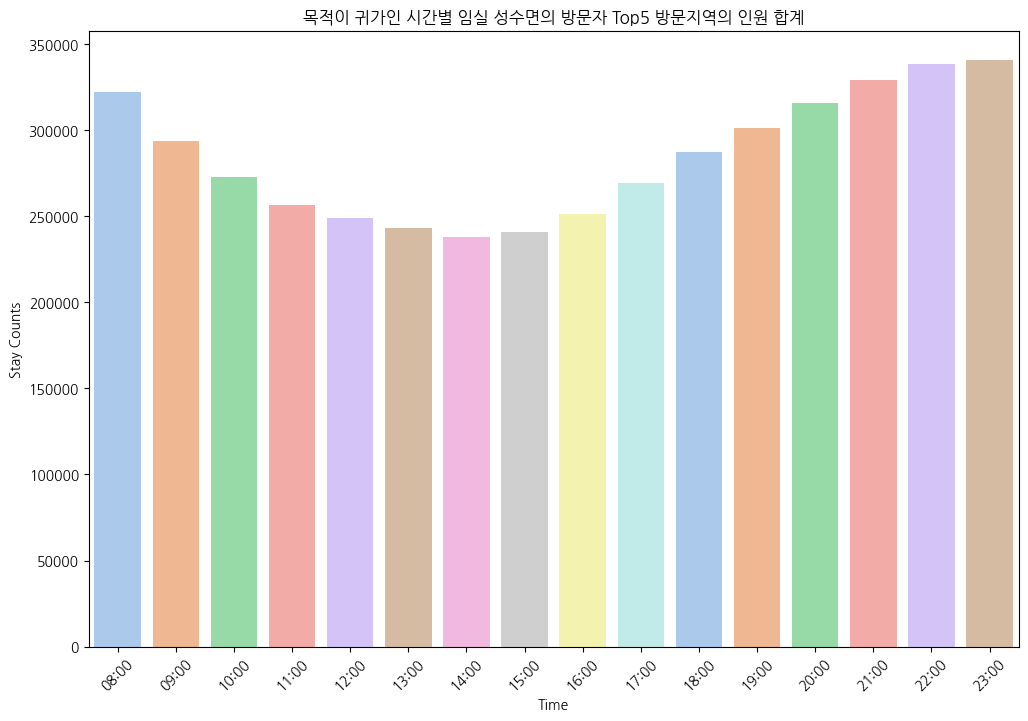

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
filtered_stay_h_I_Itop5 = filtered_stay_h_I_Itop5.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_Itop5 = filtered_stay_h_I_Itop5.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_Itop5, palette='pastel')
plt.title('목적이 귀가인 시간별 임실 성수면의 방문자 Top5 방문지역의 인원 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

# 축제 지역 stay 시간

In [13]:
stay=pd.read_csv('stay_data.csv')

In [14]:
stay

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
0,3,1156054000,20230901.0,14:00,0.0,4.0,업무,13729.0,여의동
1,578,3020055000,20230901.0,18:00,0.0,1.0,귀가,1440.0,대전광역시 유성구 도룡동
2,604,3020055000,20230901.0,21:00,1.0,1.0,귀가,1312.0,대전광역시 유성구 도룡동
3,976,3020055000,20230901.0,16:00,1.0,0.0,귀가,1646.0,대전광역시 유성구 도룡동
4,1000,2635052000,20230901.0,09:00,1.0,5.0,업무,1047.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...
323237,1168891,3020055000,20231015.0,08:00,0.0,2.0,학업,6.0,대전광역시 유성구 도룡동
323238,1169901,4575034000,20231015.0,14:00,0.0,0.0,기타,5.0,임실 성수면
323239,1172095,5115057200,20231015.0,09:00,1.0,7.0,업무,7.0,강릉시 포남2동
323240,1172333,3020055000,20231015.0,17:00,0.0,7.0,업무,10.0,대전광역시 유성구 도룡동


In [15]:
dff=stay[stay['purpose']=='귀가']
dff=dff.drop(columns = 'Unnamed: 0')
dff

,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
1,3020055000,20230901.0,18:00,0.0,1.0,귀가,1440.0,대전광역시 유성구 도룡동
2,3020055000,20230901.0,21:00,1.0,1.0,귀가,1312.0,대전광역시 유성구 도룡동
3,3020055000,20230901.0,16:00,1.0,0.0,귀가,1646.0,대전광역시 유성구 도룡동
6,5115057200,20230901.0,10:00,0.0,1.0,귀가,757.0,강릉시 포남2동
7,1156054000,20230901.0,17:00,0.0,0.0,귀가,1895.0,여의동
...,...,...,...,...,...,...,...,...
323169,4575034000,20231015.0,15:00,0.0,3.0,귀가,9.0,임실 성수면
323173,4575034000,20231015.0,15:00,0.0,1.0,귀가,6.0,임실 성수면
323177,4575034000,20231015.0,23:00,1.0,3.0,귀가,8.0,임실 성수면
323186,4575034000,20231015.0,14:00,0.0,2.0,귀가,5.0,임실 성수면


In [16]:
df=stay[stay['purpose'].isin(['쇼핑여가', '기타', '여행'])]
# df=df.drop(columns = 'Unnamed: 0')
df

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
5,1058,2635052000,20230901.0,12:00,1.0,4.0,쇼핑여가,1217.0,부산광역시 해운대구 우2동
8,1920,1156054000,20230901.0,11:00,1.0,4.0,쇼핑여가,1526.0,여의동
16,3596,5115057200,20230901.0,09:00,0.0,1.0,기타,912.0,강릉시 포남2동
17,3689,3020055000,20230901.0,10:00,0.0,3.0,기타,1333.0,대전광역시 유성구 도룡동
18,3759,1156054000,20230901.0,13:00,0.0,3.0,기타,2986.0,여의동
...,...,...,...,...,...,...,...,...,...
323232,1166391,5115058000,20231015.0,10:00,0.0,3.0,쇼핑여가,10.0,강릉시 초당동
323233,1167019,3020055000,20231015.0,22:00,0.0,4.0,쇼핑여가,10.0,대전광역시 유성구 도룡동
323235,1167604,5115058000,20231015.0,12:00,0.0,6.0,쇼핑여가,8.0,강릉시 초당동
323236,1167806,3020055000,20231015.0,10:00,0.0,7.0,쇼핑여가,9.0,대전광역시 유성구 도룡동


In [ ]:
# festival_periods = {
#     1156054000.0: ('20231007', '20231007'),              # 여의동: 2023-10-07
#     4575034000.0: ('20231006', '20231009'),              # 임실 성수면: 2023-10-06 ~ 2023-10-09
#     5115057200.0: ('20231012', '20231015'),              # 강릉시 포남2동: 2023-10-12 ~ 2023-10-15
#     5115058000.0: ('20231012', '20231015'),              # 강릉시 초당동: 2023-10-12 ~ 2023-10-15
#     2635052000.0: ('20231004', '20231013'),              # 부산광역시 해운대구 우2동: 2023-10-04 ~ 2023-10-13
#     3020055000.0: ('20231008', '20231010')               # 대전광역시 유성구 도룡동: 2023-10-08 ~ 2023-10-10
# }

In [17]:
df_s=df[(df['출발지역']=='여의동') & (df['date']== 20231007)]
df_s

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
250447,1034711,1156054000,20231007.0,19:00,0.0,0.0,기타,5317.0,여의동
250448,1034987,1156054000,20231007.0,13:00,0.0,1.0,여행,2039.0,여의동
250458,1037076,1156054000,20231007.0,21:00,1.0,3.0,기타,4018.0,여의동
250464,1039910,1156054000,20231007.0,20:00,0.0,4.0,여행,4008.0,여의동
250468,1040634,1156054000,20231007.0,18:00,0.0,6.0,기타,1352.0,여의동
...,...,...,...,...,...,...,...,...,...
257531,1097341,1156054000,20231007.0,10:00,1.0,8.0,여행,32.0,여의동
257533,1098241,1156054000,20231007.0,12:00,0.0,8.0,기타,29.0,여의동
257558,1123589,1156054000,20231007.0,13:00,0.0,8.0,기타,33.0,여의동
257611,1169856,1156054000,20231007.0,21:00,0.0,8.0,여행,25.0,여의동


<ipython-input-18-617693626c81>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_s, palette='pastel')


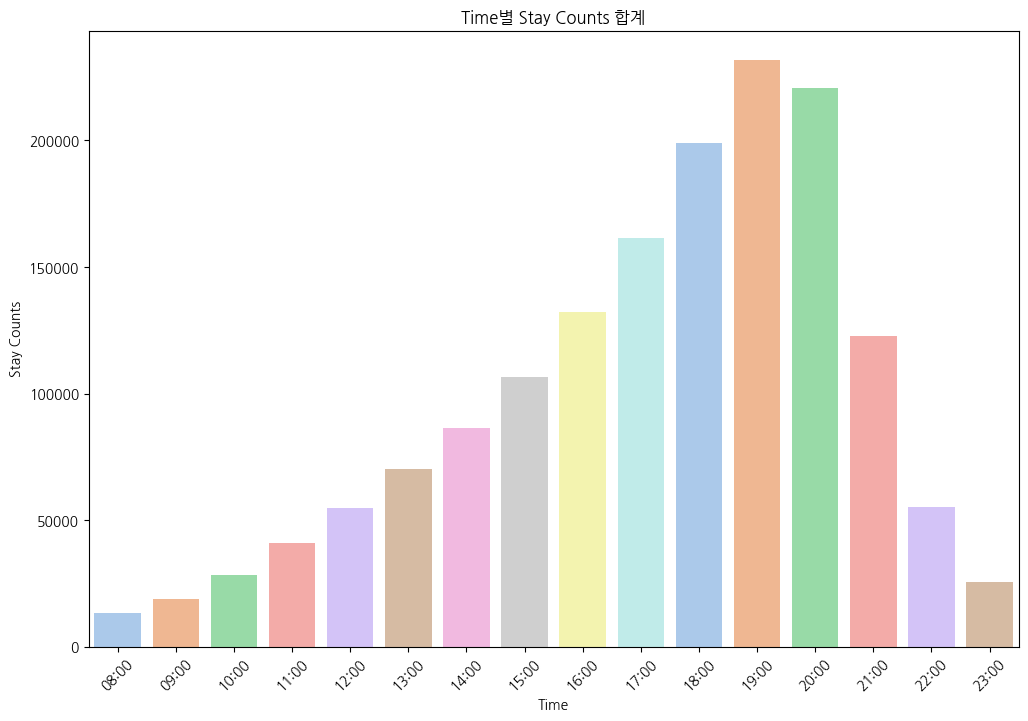

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
df_s = df_s.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_s = df_s.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_s, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()


In [ ]:
dff_s=dff[(dff['출발지역']=='여의동') & (dff['date']== 20231007)]
dff_s

,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
250449,1156054000,20231007.0,18:00,1.0,5.0,귀가,2435.0,여의동
250450,1156054000,20231007.0,18:00,1.0,3.0,귀가,2547.0,여의동
250451,1156054000,20231007.0,18:00,0.0,3.0,귀가,1936.0,여의동
250454,1156054000,20231007.0,16:00,1.0,6.0,귀가,1603.0,여의동
250455,1156054000,20231007.0,14:00,1.0,5.0,귀가,2242.0,여의동
...,...,...,...,...,...,...,...,...
256744,1156054000,20231007.0,23:00,1.0,1.0,귀가,1622.0,여의동
256750,1156054000,20231007.0,13:00,1.0,4.0,귀가,2301.0,여의동
256783,1156054000,20231007.0,10:00,0.0,8.0,귀가,428.0,여의동
256798,1156054000,20231007.0,16:00,0.0,8.0,귀가,437.0,여의동


<ipython-input-12-5f45464d4ad4>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped, palette='pastel')


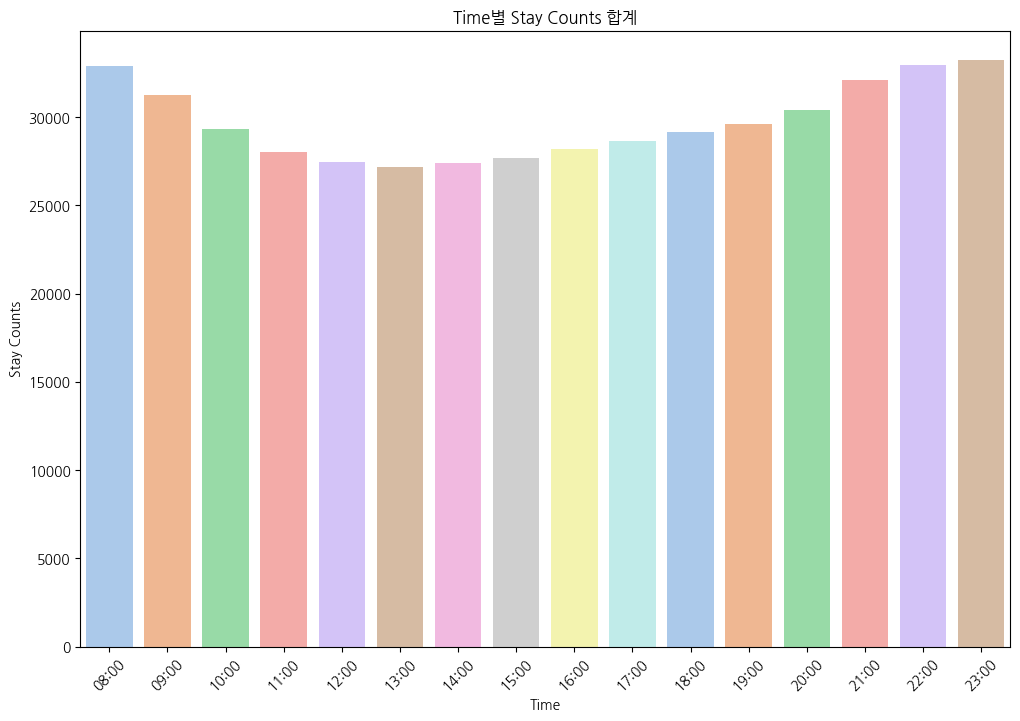

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
dff_s = dff_s.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped = dff_s.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()


In [27]:
df_b=df[(df['출발지역']=='부산광역시 해운대구 우2동') & (df['date']>= 20231004) & (df['date'] <= 20231013)]
df_b

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
236082,622556,2635052000,20231004.0,15:00,1.0,2.0,여행,657.0,부산광역시 해운대구 우2동
236094,624620,2635052000,20231004.0,19:00,1.0,3.0,쇼핑여가,702.0,부산광역시 해운대구 우2동
236134,634724,2635052000,20231004.0,14:00,1.0,1.0,기타,762.0,부산광역시 해운대구 우2동
236173,645432,2635052000,20231004.0,15:00,0.0,3.0,기타,644.0,부산광역시 해운대구 우2동
236176,645654,2635052000,20231004.0,16:00,1.0,4.0,쇼핑여가,835.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...,...
308622,567503,2635052000,20231013.0,16:00,0.0,8.0,여행,5.0,부산광역시 해운대구 우2동
308661,595193,2635052000,20231013.0,09:00,1.0,7.0,쇼핑여가,18.0,부산광역시 해운대구 우2동
308680,612039,2635052000,20231013.0,22:00,1.0,8.0,기타,18.0,부산광역시 해운대구 우2동
308682,612418,2635052000,20231013.0,14:00,1.0,8.0,여행,8.0,부산광역시 해운대구 우2동


<ipython-input-28-a4d7781f695c>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_b, palette='pastel')


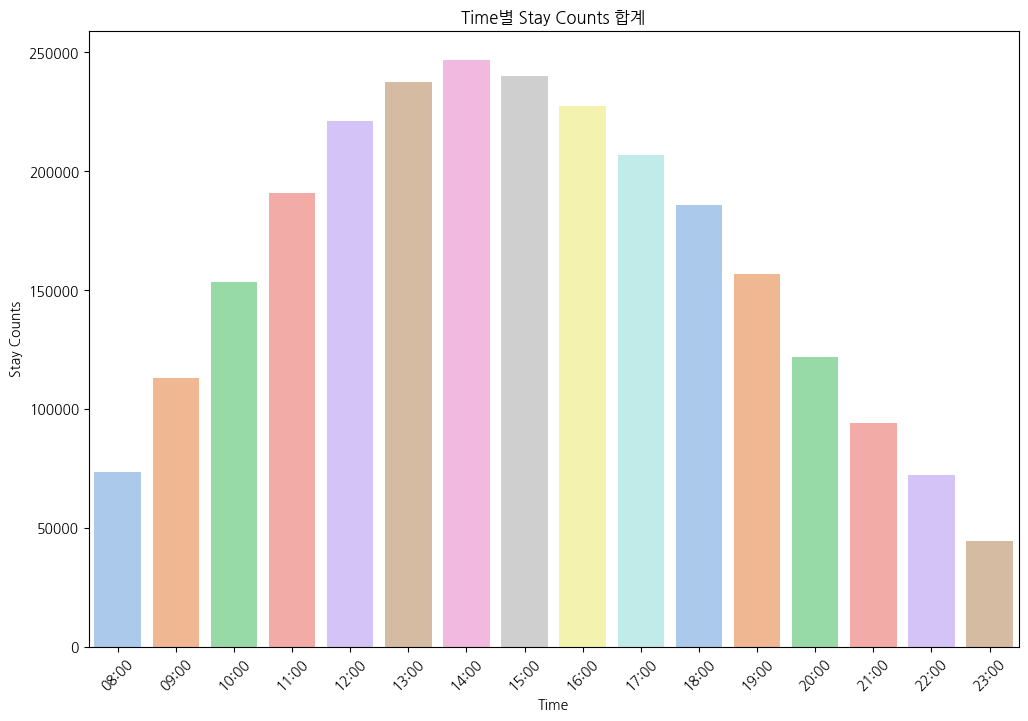

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
df_b = df_b.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_b = df_b.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_b, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()


In [ ]:
dff_b=dff[(dff['출발지역']=='부산광역시 해운대구 우2동') & (dff['date']>= 20231004) & (dff['date'] <= 20231013)]
dff_b

,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
236013,2635052000,20231004.0,13:00,0.0,5.0,귀가,900.0,부산광역시 해운대구 우2동
236014,2635052000,20231004.0,20:00,1.0,3.0,귀가,2159.0,부산광역시 해운대구 우2동
236039,2635052000,20231004.0,09:00,1.0,3.0,귀가,1699.0,부산광역시 해운대구 우2동
236040,2635052000,20231004.0,20:00,0.0,0.0,귀가,1546.0,부산광역시 해운대구 우2동
236051,2635052000,20231004.0,08:00,0.0,6.0,귀가,1030.0,부산광역시 해운대구 우2동
...,...,...,...,...,...,...,...,...
307644,2635052000,20231013.0,18:00,1.0,8.0,귀가,406.0,부산광역시 해운대구 우2동
307649,2635052000,20231013.0,23:00,0.0,8.0,귀가,317.0,부산광역시 해운대구 우2동
307665,2635052000,20231013.0,08:00,1.0,8.0,귀가,400.0,부산광역시 해운대구 우2동
307731,2635052000,20231013.0,20:00,0.0,8.0,귀가,317.0,부산광역시 해운대구 우2동


<ipython-input-16-11b5dc2824a7>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped, palette='pastel')


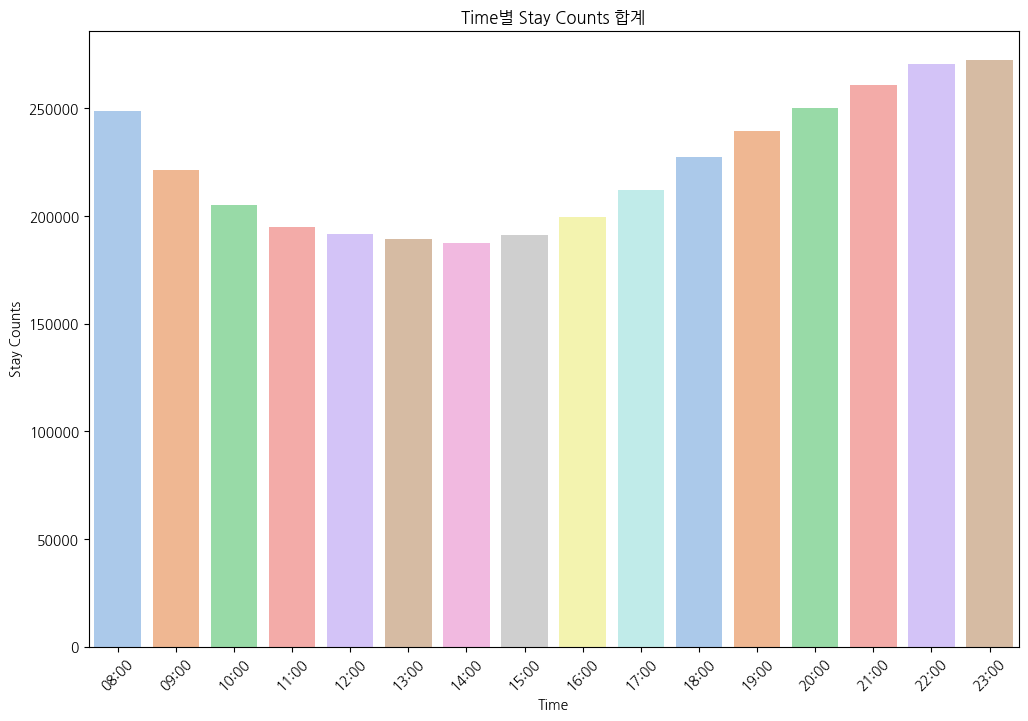

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
dff_b = dff_b.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped = dff_b.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_ga=df[(df['출발지역']=='강릉시 포남2동') & (df['date']>= 20231012) & (df['date'] <= 20231015)]
df_ga

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
294489,243432,5115057200,20231012.0,13:00,1.0,4.0,기타,514.0,강릉시 포남2동
294624,285679,5115057200,20231012.0,13:00,1.0,5.0,기타,332.0,강릉시 포남2동
294665,301289,5115057200,20231012.0,15:00,1.0,5.0,기타,367.0,강릉시 포남2동
294697,312989,5115057200,20231012.0,09:00,0.0,1.0,기타,272.0,강릉시 포남2동
294701,314027,5115057200,20231012.0,11:00,1.0,5.0,기타,244.0,강릉시 포남2동
...,...,...,...,...,...,...,...,...,...
323198,1142346,5115057200,20231015.0,21:00,0.0,6.0,쇼핑여가,9.0,강릉시 포남2동
323214,1150196,5115057200,20231015.0,09:00,0.0,5.0,쇼핑여가,7.0,강릉시 포남2동
323217,1151427,5115057200,20231015.0,08:00,1.0,7.0,여행,5.0,강릉시 포남2동
323223,1157493,5115057200,20231015.0,13:00,1.0,8.0,쇼핑여가,5.0,강릉시 포남2동


<ipython-input-115-adffeefc0f2e>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_ga, palette='pastel')


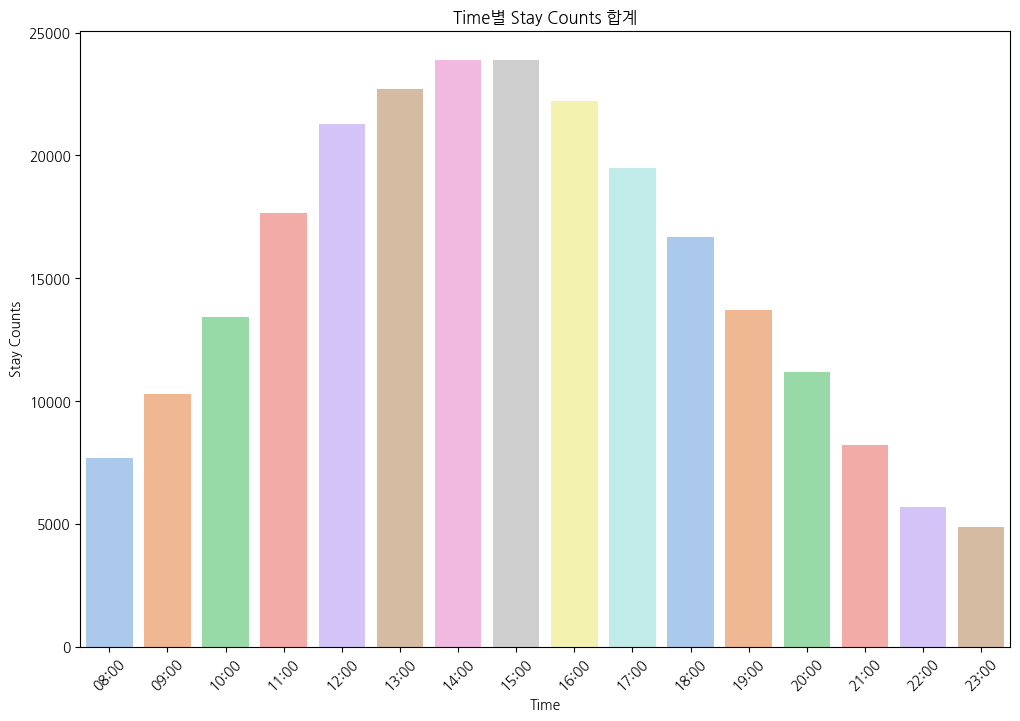

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
df_ga = df_ga.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_ga = df_ga.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_ga, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

In [ ]:
dff_ga=dff[(dff['출발지역']=='강릉시 포남2동') & (dff['date']>= 20231012) & (dff['date'] <= 20231015)]
dff_ga

,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
294202,5115057200,20231012.0,13:00,1.0,5.0,귀가,646.0,강릉시 포남2동
294238,5115057200,20231012.0,20:00,0.0,4.0,귀가,719.0,강릉시 포남2동
294261,5115057200,20231012.0,19:00,0.0,5.0,귀가,761.0,강릉시 포남2동
294289,5115057200,20231012.0,20:00,0.0,5.0,귀가,804.0,강릉시 포남2동
294339,5115057200,20231012.0,21:00,1.0,5.0,귀가,1083.0,강릉시 포남2동
...,...,...,...,...,...,...,...,...
322594,5115057200,20231015.0,21:00,0.0,8.0,귀가,94.0,강릉시 포남2동
322639,5115057200,20231015.0,17:00,0.0,8.0,귀가,89.0,강릉시 포남2동
322647,5115057200,20231015.0,11:00,0.0,8.0,귀가,92.0,강릉시 포남2동
322671,5115057200,20231015.0,15:00,0.0,8.0,귀가,81.0,강릉시 포남2동


<ipython-input-20-431f1f578542>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped, palette='pastel')


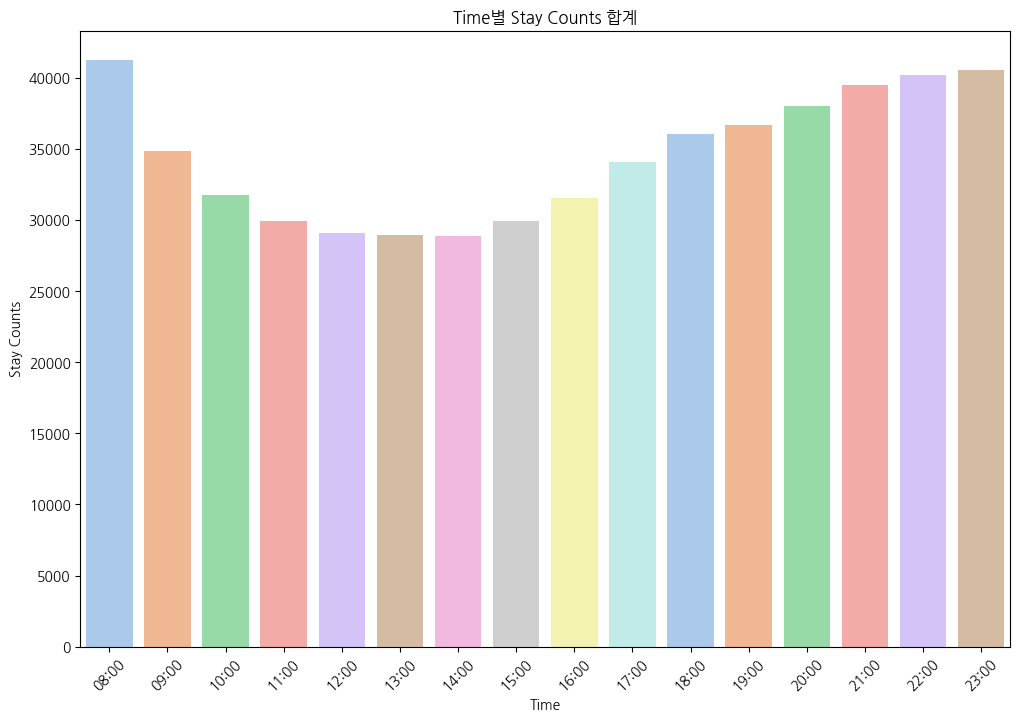

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
dff_ga = dff_ga.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped = dff_ga.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_gb=df[(df['출발지역']=='강릉시 초당동') & (df['date']>= 20231012) & (df['date'] <= 20231015)]
df_gb

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
294183,166308,5115058000,20231012.0,13:00,0.0,1.0,기타,889.0,강릉시 초당동
294378,212562,5115058000,20231012.0,08:00,0.0,1.0,기타,868.0,강릉시 초당동
294386,215306,5115058000,20231012.0,12:00,0.0,1.0,기타,924.0,강릉시 초당동
294462,233744,5115058000,20231012.0,16:00,0.0,1.0,기타,791.0,강릉시 초당동
294688,308685,5115058000,20231012.0,22:00,1.0,3.0,여행,259.0,강릉시 초당동
...,...,...,...,...,...,...,...,...,...
323212,1148034,5115058000,20231015.0,10:00,1.0,3.0,쇼핑여가,7.0,강릉시 초당동
323215,1150280,5115058000,20231015.0,19:00,1.0,8.0,기타,10.0,강릉시 초당동
323228,1159853,5115058000,20231015.0,22:00,1.0,8.0,여행,5.0,강릉시 초당동
323232,1166391,5115058000,20231015.0,10:00,0.0,3.0,쇼핑여가,10.0,강릉시 초당동


<ipython-input-122-d5492096da19>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_gb, palette='pastel')


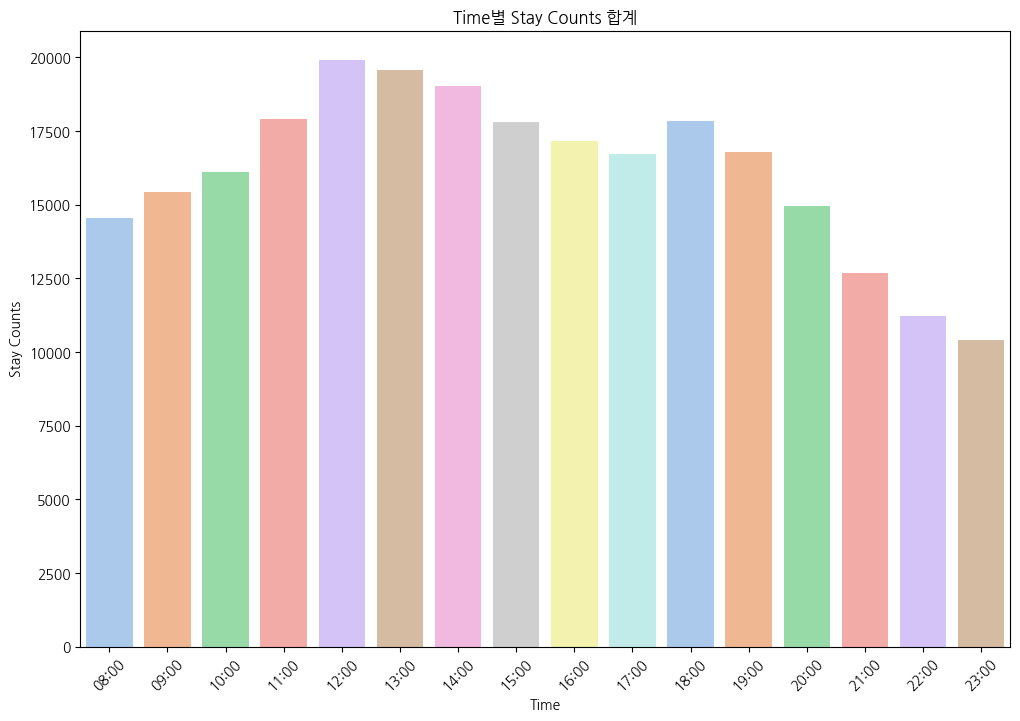

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
df_gb = df_gb.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_gb = df_gb.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_gb, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_I=df[(df['출발지역']=='임실 성수면') & (df['date']>= 20231006) & (df['date'] <= 20231009)]
df_I

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
250656,1085436,4575034000,20231007.0,15:00,0.0,4.0,기타,694.0,임실 성수면
250740,1107464,4575034000,20231007.0,14:00,1.0,6.0,기타,532.0,임실 성수면
250744,1108452,4575034000,20231007.0,14:00,0.0,3.0,기타,455.0,임실 성수면
250818,1126850,4575034000,20231007.0,12:00,1.0,5.0,기타,564.0,임실 성수면
250832,1131663,4575034000,20231007.0,17:00,1.0,5.0,기타,460.0,임실 성수면
...,...,...,...,...,...,...,...,...,...
279788,880584,4575034000,20231009.0,15:00,0.0,0.0,기타,18.0,임실 성수면
279796,886679,4575034000,20231009.0,16:00,0.0,1.0,여행,13.0,임실 성수면
279799,888382,4575034000,20231009.0,16:00,0.0,0.0,여행,7.0,임실 성수면
279802,889377,4575034000,20231009.0,18:00,0.0,6.0,여행,17.0,임실 성수면


<ipython-input-137-78b28a2fea8c>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_I, palette='pastel')


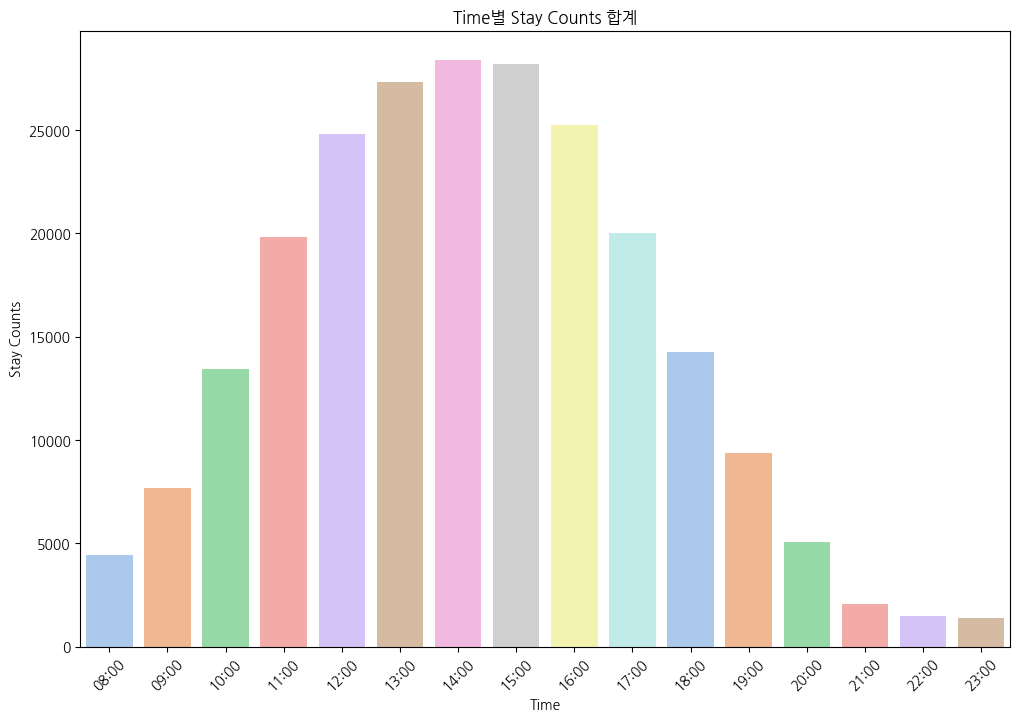

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
df_I = df_I.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_I = df_I.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_I, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_d=df[(df['출발지역']=='대전광역시 유성구 도룡동') & (df['date']>= 20231008) & (df['date'] <= 20231010)]
df_d

,Unnamed: 0,hdong_cd,date,time,gender,age,purpose,stay_cnts,출발지역
265261,446387,3020055000,20231008.0,17:00,1.0,0.0,쇼핑여가,641.0,대전광역시 유성구 도룡동
265282,452391,3020055000,20231008.0,14:00,1.0,3.0,기타,645.0,대전광역시 유성구 도룡동
265321,459214,3020055000,20231008.0,13:00,1.0,3.0,여행,835.0,대전광역시 유성구 도룡동
265332,460945,3020055000,20231008.0,14:00,0.0,0.0,쇼핑여가,766.0,대전광역시 유성구 도룡동
265352,466259,3020055000,20231008.0,14:00,0.0,4.0,쇼핑여가,801.0,대전광역시 유성구 도룡동
...,...,...,...,...,...,...,...,...,...
286918,1056464,3020055000,20231010.0,11:00,0.0,8.0,기타,13.0,대전광역시 유성구 도룡동
286929,1070011,3020055000,20231010.0,17:00,1.0,8.0,여행,5.0,대전광역시 유성구 도룡동
286931,1071719,3020055000,20231010.0,22:00,0.0,7.0,여행,10.0,대전광역시 유성구 도룡동
286957,1087930,3020055000,20231010.0,16:00,1.0,8.0,쇼핑여가,5.0,대전광역시 유성구 도룡동


<ipython-input-105-05259e9f9aae>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time', y='stay_cnts', data=time_grouped_d, palette='pastel')


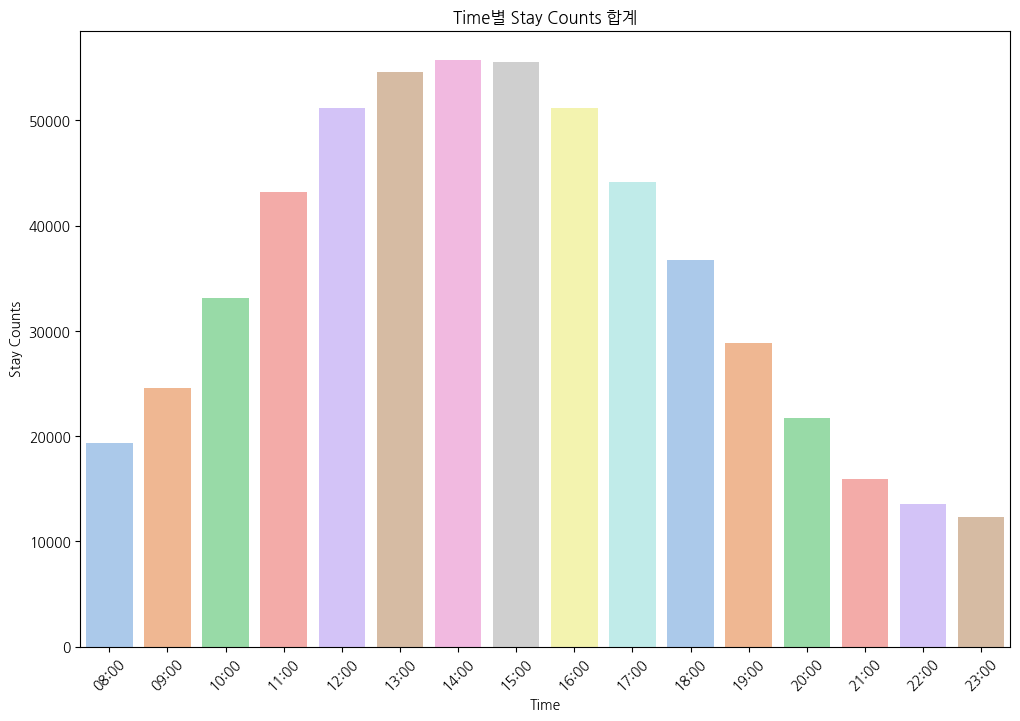

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
# time별로 stay_cnts를 합산
df_d = df_d.dropna(subset=['time', 'stay_cnts'])

# time별로 stay_cnts를 합산
time_grouped_d = df_d.groupby('time')['stay_cnts'].sum().reset_index()

# 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x='time', y='stay_cnts', data=time_grouped_d, palette='pastel')
plt.title('Time별 Stay Counts 합계')
plt.xlabel('Time')
plt.ylabel('Stay Counts')
plt.xticks(rotation=45)
plt.show()

# 합친 그래프


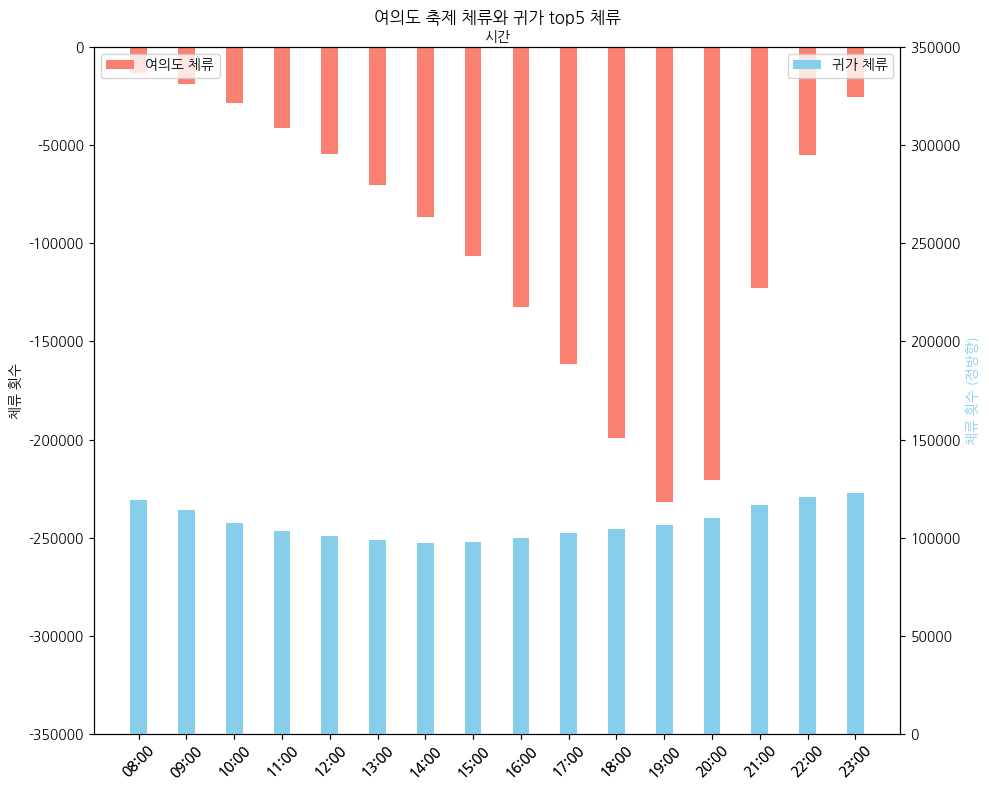

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
time2 = time_grouped_Stop5['time']
stay_cnts2 = time_grouped_Stop5['stay_cnts']

time1 = time_grouped_s['time']
stay_cnts1 = time_grouped_s['stay_cnts']

# 막대 그래프의 폭 설정
bar_width = 0.35
index1 = np.arange(len(time1))
index2 = np.arange(len(time2))

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 8))

# 상하반전된 막대 그래프 (음수값을 위로)
ax1.bar(index1, [-v for v in stay_cnts1], width=bar_width, color='salmon', label='여의도 체류')
ax1.set_xlabel('시간')
ax1.set_ylabel('체류 횟수')
ax1.set_title('여의도 축제 체류와 귀가 top5 체류')

# x축 레이블을 상단과 하단에 배치
ax1.xaxis.set_label_position('bottom')
ax1.set_xticks(np.concatenate((index1, index2)))
ax1.set_xticklabels(np.concatenate((time1, time2)), rotation=45)

# 두 번째 y축 (같은 x축에 다른 데이터 사용)
ax2 = ax1.twinx()

# 정방향 막대 그래프
ax2.bar(index2, stay_cnts2, width=bar_width, color='skyblue', label='귀가 체류')
ax2.set_ylabel('체류 횟수 (정방향)', color='skyblue')

# x축 레이블을 위쪽에 배치
ax1.xaxis.set_label_position('top')

# y축의 범위 설정 (500000으로 설정)
ax1.set_ylim([-350000, 0])  # 음수값 범위
ax2.set_ylim([0, 350000])   # 양수값 범위

# 범례 추가
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 그래프 표시
plt.tight_layout()
plt.show()


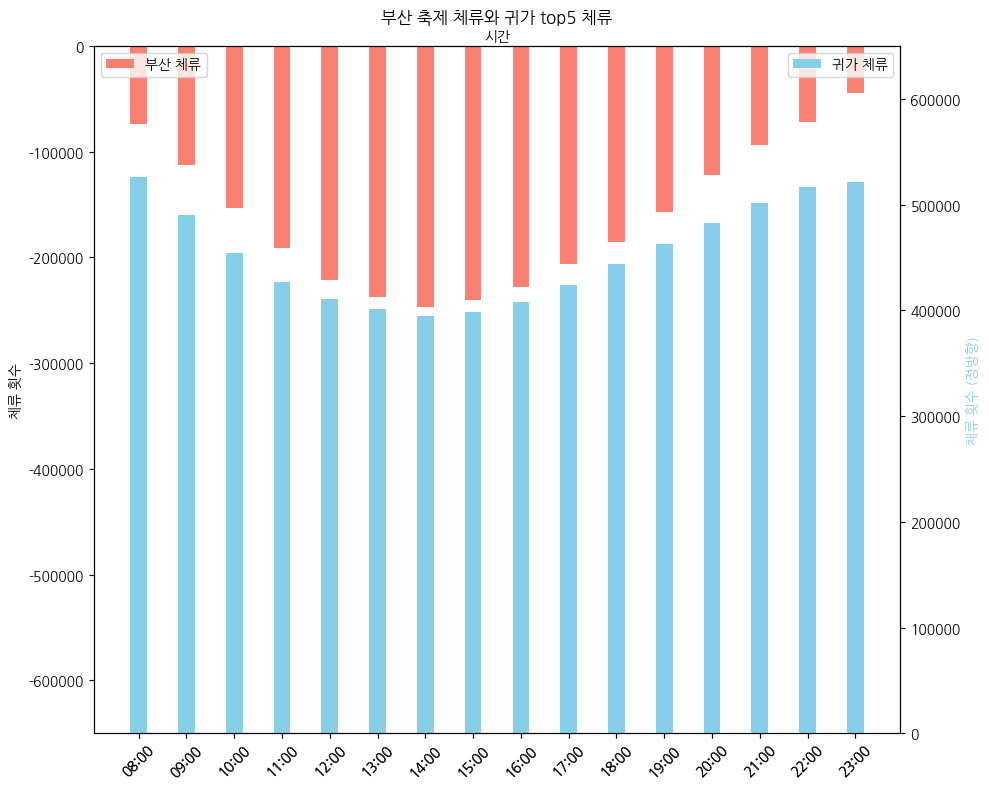

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
time2 = time_grouped_Btop5['time']
stay_cnts2 = time_grouped_Btop5['stay_cnts']

time1 = time_grouped_b['time']
stay_cnts1 = time_grouped_b['stay_cnts']

# 막대 그래프의 폭 설정
bar_width = 0.35
index1 = np.arange(len(time1))
index2 = np.arange(len(time2))

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 8))

# 상하반전된 막대 그래프 (음수값을 위로)
ax1.bar(index1, [-v for v in stay_cnts1], width=bar_width, color='salmon', label='부산 체류')
ax1.set_xlabel('시간')
ax1.set_ylabel('체류 횟수')
ax1.set_title('부산 축제 체류와 귀가 top5 체류')

# x축 레이블을 상단과 하단에 배치
ax1.xaxis.set_label_position('bottom')
ax1.set_xticks(np.concatenate((index1, index2)))
ax1.set_xticklabels(np.concatenate((time1, time2)), rotation=45)

# 두 번째 y축 (같은 x축에 다른 데이터 사용)
ax2 = ax1.twinx()

# 정방향 막대 그래프
ax2.bar(index2, stay_cnts2, width=bar_width, color='skyblue', label='귀가 체류')
ax2.set_ylabel('체류 횟수 (정방향)', color='skyblue')

# x축 레이블을 위쪽에 배치
ax1.xaxis.set_label_position('top')

# y축의 범위 설정 (양옆의 y축을 동일한 범위로 설정)
y_max = max(max(stay_cnts1), max(stay_cnts2))  # 양의 최대값
y_min = min(min(stay_cnts1), min(stay_cnts2))  # 음의 최대값

# y축 범위 설정 (절댓값을 기준으로 범위 설정)
y_range = max(abs(y_min), abs(y_max))  # 최대값의 절댓값을 기준으로 범위 설정

# 첫 번째 y축 (상하반전된 값은 그대로 두고 양옆의 범위는 같게 설정)
ax1.set_ylim([-650000, 0])  # 음수값 범위
ax2.set_ylim([0,650000])   # 양수값 범위

# 범례 추가
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 그래프 표시
plt.tight_layout()
plt.show()



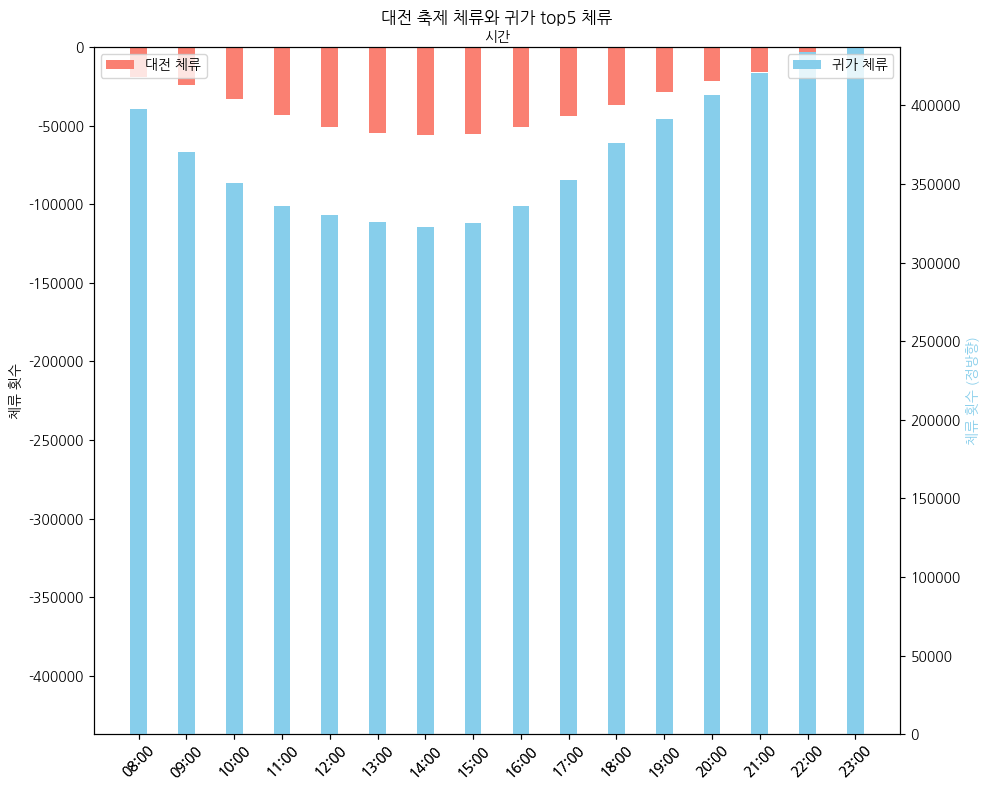

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
time2 = time_grouped_Dtop5['time']
stay_cnts2 = time_grouped_Dtop5['stay_cnts']

time1 = time_grouped_d['time']
stay_cnts1 = time_grouped_d['stay_cnts']

# 막대 그래프의 폭 설정
bar_width = 0.35
index1 = np.arange(len(time1))
index2 = np.arange(len(time2))

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 8))

# 상하반전된 막대 그래프 (음수값을 위로)
ax1.bar(index1, [-v for v in stay_cnts1], width=bar_width, color='salmon', label='대전 체류')
ax1.set_xlabel('시간')
ax1.set_ylabel('체류 횟수')
ax1.set_title('대전 축제 체류와 귀가 top5 체류')

# x축 레이블을 상단과 하단에 배치
ax1.xaxis.set_label_position('bottom')
ax1.set_xticks(np.concatenate((index1, index2)))
ax1.set_xticklabels(np.concatenate((time1, time2)), rotation=45)

# 두 번째 y축 (같은 x축에 다른 데이터 사용)
ax2 = ax1.twinx()

# 정방향 막대 그래프
ax2.bar(index2, stay_cnts2, width=bar_width, color='skyblue', label='귀가 체류')
ax2.set_ylabel('체류 횟수 (정방향)', color='skyblue')

# x축 레이블을 위쪽에 배치
ax1.xaxis.set_label_position('top')

# y축의 범위 설정 (양옆의 y축을 동일한 범위로 설정)
y_max = max(max(stay_cnts1), max(stay_cnts2))  # 양의 최대값
y_min = min(min(stay_cnts1), min(stay_cnts2))  # 음의 최대값

# y축 범위 설정 (절댓값을 기준으로 범위 설정)
y_range = max(abs(y_min), abs(y_max))  # 최대값의 절댓값을 기준으로 범위 설정

# 첫 번째 y축 (상하반전된 값은 그대로 두고 양옆의 범위는 같게 설정)
ax1.set_ylim([-y_range, 0])  # 음수값 범위
ax2.set_ylim([0, y_range])   # 양수값 범위

# 범례 추가
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 그래프 표시
plt.tight_layout()
plt.show()



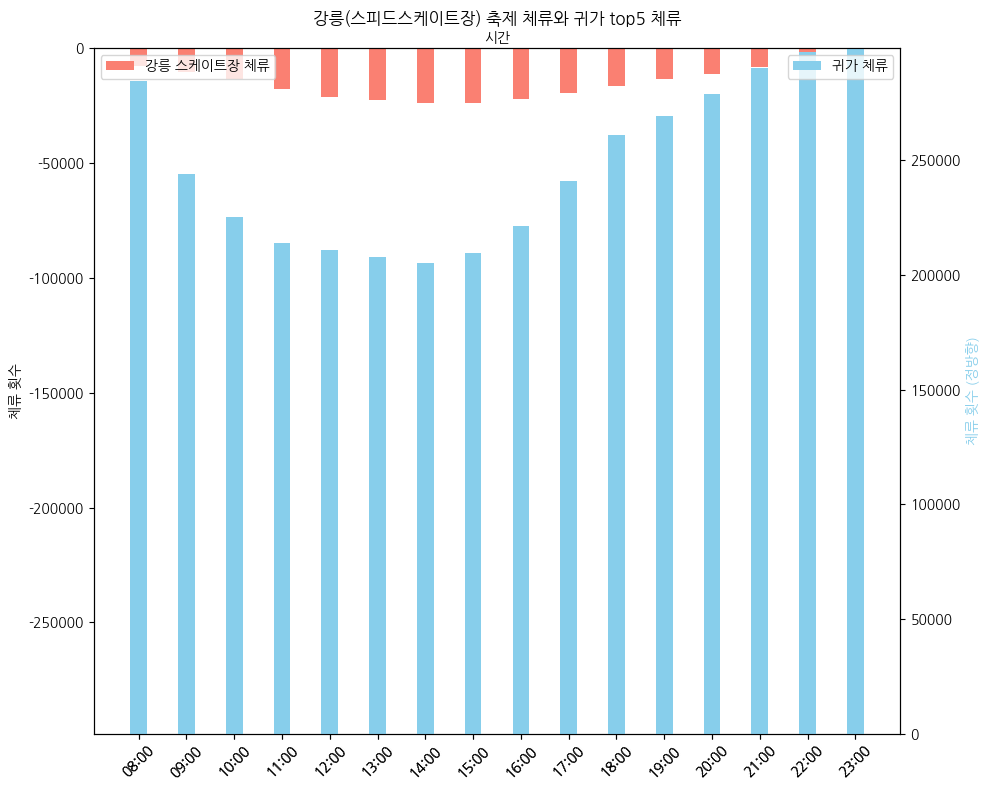

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
time2 = time_grouped_Gtop5['time']
stay_cnts2 = time_grouped_Gtop5['stay_cnts']

time1 = time_grouped_ga['time']
stay_cnts1 = time_grouped_ga['stay_cnts']

# 막대 그래프의 폭 설정
bar_width = 0.35
index1 = np.arange(len(time1))
index2 = np.arange(len(time2))

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 8))

# 상하반전된 막대 그래프 (음수값을 위로)
ax1.bar(index1, [-v for v in stay_cnts1], width=bar_width, color='salmon', label='강릉 스케이트장 체류')
ax1.set_xlabel('시간')
ax1.set_ylabel('체류 횟수')
ax1.set_title('강릉(스피드스케이트장) 축제 체류와 귀가 top5 체류')

# x축 레이블을 상단과 하단에 배치
ax1.xaxis.set_label_position('bottom')
ax1.set_xticks(np.concatenate((index1, index2)))
ax1.set_xticklabels(np.concatenate((time1, time2)), rotation=45)

# 두 번째 y축 (같은 x축에 다른 데이터 사용)
ax2 = ax1.twinx()

# 정방향 막대 그래프
ax2.bar(index2, stay_cnts2, width=bar_width, color='skyblue', label='귀가 체류')
ax2.set_ylabel('체류 횟수 (정방향)', color='skyblue')

# x축 레이블을 위쪽에 배치
ax1.xaxis.set_label_position('top')

# y축의 범위 설정 (양옆의 y축을 동일한 범위로 설정)
y_max = max(max(stay_cnts1), max(stay_cnts2))  # 양의 최대값
y_min = min(min(stay_cnts1), min(stay_cnts2))  # 음의 최대값

# y축 범위 설정 (절댓값을 기준으로 범위 설정)
y_range = max(abs(y_min), abs(y_max))  # 최대값의 절댓값을 기준으로 범위 설정

# 첫 번째 y축 (상하반전된 값은 그대로 두고 양옆의 범위는 같게 설정)
ax1.set_ylim([-y_range, 0])  # 음수값 범위
ax2.set_ylim([0, y_range])   # 양수값 범위

# 범례 추가
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 그래프 표시
plt.tight_layout()
plt.show()



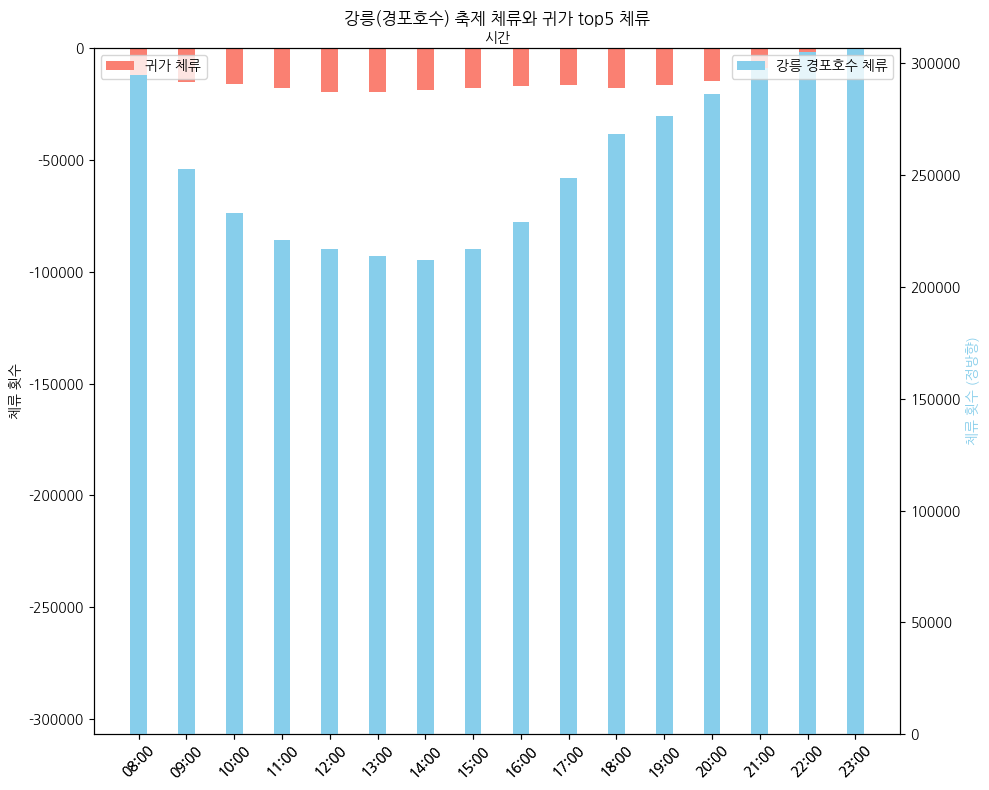

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
time2 = time_grouped_G2top5['time']
stay_cnts2 = time_grouped_G2top5['stay_cnts']

time1 = time_grouped_gb['time']
stay_cnts1 = time_grouped_gb['stay_cnts']

# 막대 그래프의 폭 설정
bar_width = 0.35
index1 = np.arange(len(time1))
index2 = np.arange(len(time2))

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 8))

# 상하반전된 막대 그래프 (음수값을 위로)
ax1.bar(index1, [-v for v in stay_cnts1], width=bar_width, color='salmon', label='귀가 체류')
ax1.set_xlabel('시간')
ax1.set_ylabel('체류 횟수')
ax1.set_title('강릉(경포호수) 축제 체류와 귀가 top5 체류')

# x축 레이블을 상단과 하단에 배치
ax1.xaxis.set_label_position('bottom')
ax1.set_xticks(np.concatenate((index1, index2)))
ax1.set_xticklabels(np.concatenate((time1, time2)), rotation=45)

# 두 번째 y축 (같은 x축에 다른 데이터 사용)
ax2 = ax1.twinx()

# 정방향 막대 그래프
ax2.bar(index2, stay_cnts2, width=bar_width, color='skyblue', label='강릉 경포호수 체류')
ax2.set_ylabel('체류 횟수 (정방향)', color='skyblue')

# x축 레이블을 위쪽에 배치
ax1.xaxis.set_label_position('top')

# y축의 범위 설정 (양옆의 y축을 동일한 범위로 설정)
y_max = max(max(stay_cnts1), max(stay_cnts2))  # 양의 최대값
y_min = min(min(stay_cnts1), min(stay_cnts2))  # 음의 최대값

# y축 범위 설정 (절댓값을 기준으로 범위 설정)
y_range = max(abs(y_min), abs(y_max))  # 최대값의 절댓값을 기준으로 범위 설정

# 첫 번째 y축 (상하반전된 값은 그대로 두고 양옆의 범위는 같게 설정)
ax1.set_ylim([-y_range, 0])  # 음수값 범위
ax2.set_ylim([0, y_range])   # 양수값 범위

# 범례 추가
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 그래프 표시
plt.tight_layout()
plt.show()



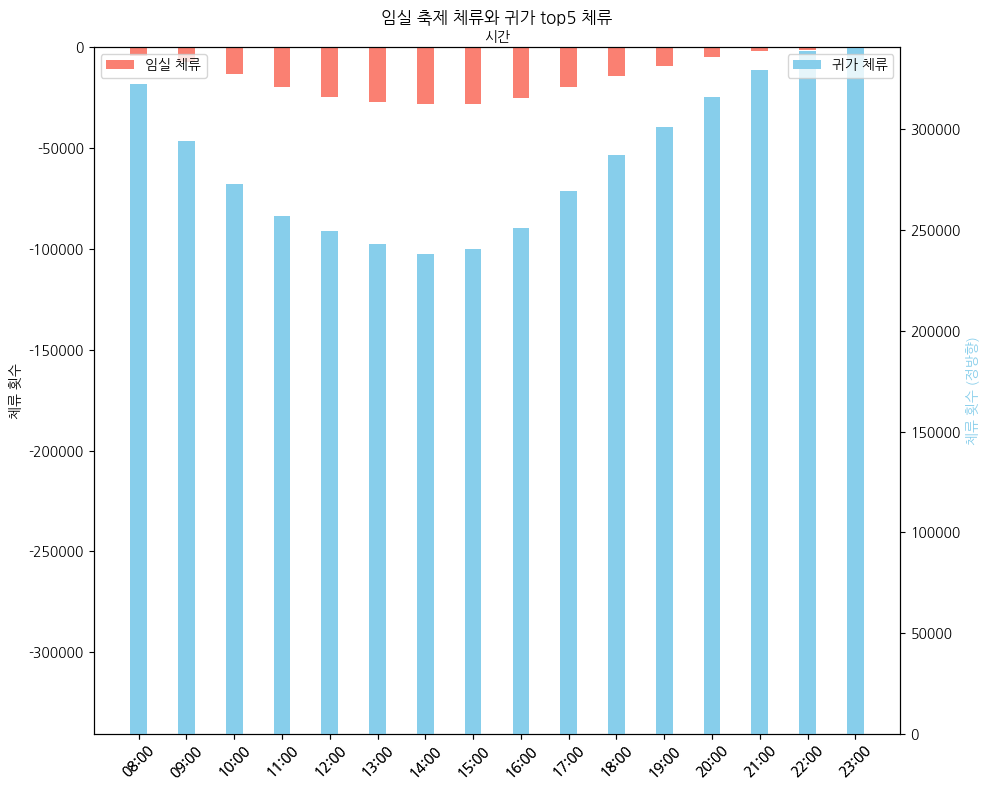

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
time2 = time_grouped_Itop5['time']
stay_cnts2 = time_grouped_Itop5['stay_cnts']

time1 = time_grouped_I['time']
stay_cnts1 = time_grouped_I['stay_cnts']

# 막대 그래프의 폭 설정
bar_width = 0.35
index1 = np.arange(len(time1))
index2 = np.arange(len(time2))

# 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 8))

# 상하반전된 막대 그래프 (음수값을 위로)
ax1.bar(index1, [-v for v in stay_cnts1], width=bar_width, color='salmon', label='임실 체류')
ax1.set_xlabel('시간')
ax1.set_ylabel('체류 횟수')
ax1.set_title('임실 축제 체류와 귀가 top5 체류')

# x축 레이블을 상단과 하단에 배치
ax1.xaxis.set_label_position('bottom')
ax1.set_xticks(np.concatenate((index1, index2)))
ax1.set_xticklabels(np.concatenate((time1, time2)), rotation=45)

# 두 번째 y축 (같은 x축에 다른 데이터 사용)
ax2 = ax1.twinx()

# 정방향 막대 그래프
ax2.bar(index2, stay_cnts2, width=bar_width, color='skyblue', label='귀가 체류')
ax2.set_ylabel('체류 횟수 (정방향)', color='skyblue')

# x축 레이블을 위쪽에 배치
ax1.xaxis.set_label_position('top')

# y축의 범위 설정 (양옆의 y축을 동일한 범위로 설정)
y_max = max(max(stay_cnts1), max(stay_cnts2))  # 양의 최대값
y_min = min(min(stay_cnts1), min(stay_cnts2))  # 음의 최대값

# y축 범위 설정 (절댓값을 기준으로 범위 설정)
y_range = max(abs(y_min), abs(y_max))  # 최대값의 절댓값을 기준으로 범위 설정

# 첫 번째 y축 (상하반전된 값은 그대로 두고 양옆의 범위는 같게 설정)
ax1.set_ylim([-y_range, 0])  # 음수값 범위
ax2.set_ylim([0, y_range])   # 양수값 범위

# 범례 추가
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 그래프 표시
plt.tight_layout()
plt.show()

